# Phase 1: Exploratory Analysis — Superstore Dataset

**Notebook Objective:** 
> This notebook is to perform a structured exploratory analysis (Phase 2) of the superstore data.
>
> The purpose is to identify relevant trends, anomalies, and potential performance drivers that can guide deeper diagnostic analysis in the next phase of the project.

---
**Contents:**

1. Setup
2. Exploratory Data Analysis
 - 2.1 Business Overview
 - 2.2 Profitability Drivers
 - 2.3 Geographic Profitability
 - 2.4 Product & Customer Concentration
 - 2.5 Growth & Seasonality
 - 2.6 Distribution & Outliers
3. Key Findings & Phase 2 Direction

---
## 1. Setup

In [1]:
# Import libraries
import sqlite3
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
from pathlib import Path

# Define paths
ROOT = Path().resolve().parent
DB_PATH = ROOT / "data" / "superstore.db"
SQL_PATH = ROOT / "sql"
VISUALS_PATH = ROOT / "visuals"

VISUALS_PATH.mkdir(exist_ok=True)

conn = sqlite3.connect(DB_PATH)

def run_sql_file(filepath):
    """Read a .sql file, strip comments, and return a list of DataFrames — one per statement."""
    with open(filepath) as f:
        content = f.read()
    content = re.sub(r'--[^\n]*', '', content)          # strip line comments
    statements = [s.strip() for s in content.split(';') if s.strip()]
    return [pd.read_sql_query(s, conn) for s in statements]

def fmt_usd(val):
    return f'${val:,.0f}'

print('Connected to', DB_PATH)

Connected to /Users/josuxx/ai_space/workspace/01_projects/superstore-sales-analysis/data/superstore.db


---
## 2. Exploratory Data Analysis (EDA)

---
### 2.1 Business Overview

In [3]:
results = run_sql_file(SQL_PATH / "01_global_metrics.sql")

kpis = results[0].T
kpis.columns = ['Value']
kpis

,Value
total_line_items,"9,993.0"
total_sales,"2,296,919.0"
total_profit,"286,409.0"
margin_pct,12.5
total_customers,793.0
total_orders,"5,009.0"
loss_items,"1,870.0"
loss_rate_pct,18.7
discounted_items,"5,195.0"
discount_rate_pct,52.0


**Key Observations:**

- The business generated **$2.3M in sales** and **$286K in profit** from **5,009 orders** and **793 customers**, resulting in a **12.5% overall margin**.

- Surface profitability hides margin leakage: **18.7% of line items are unprofitable**, meaning nearly **1 in 5 items** sells at a loss.

- Discounting is widespread: **52% of line items** include a discount, making pricing discipline a key area to investigate next.

The global KPIs show that Superstore is profitable overall, but they also reveal two early warning signs: a high loss-item rate and widespread discounting. The next step is to identify which business drivers are most associated with this margin leakage.

---
### 2.2 Profitability Drivers

---
#### 2.2.1 Category and Sub-Category Performance

**Sales, Profit, and Margin by Category**

In [4]:
results = run_sql_file(SQL_PATH / "02_by_category.sql")
cat_df  = results[0]
sub_df  = results[1]

print('=== Category ===')
display(cat_df)

=== Category ===


,Category,sales,sales_pct,profit,profit_pct,margin_pct
0,Technology,"836,154.0",36.4,"145,455.0",50.8,17.4
1,Furniture,"741,718.0",32.3,"18,463.0",6.4,2.5
2,Office Supplies,"719,047.0",31.3,"122,491.0",42.8,17.0


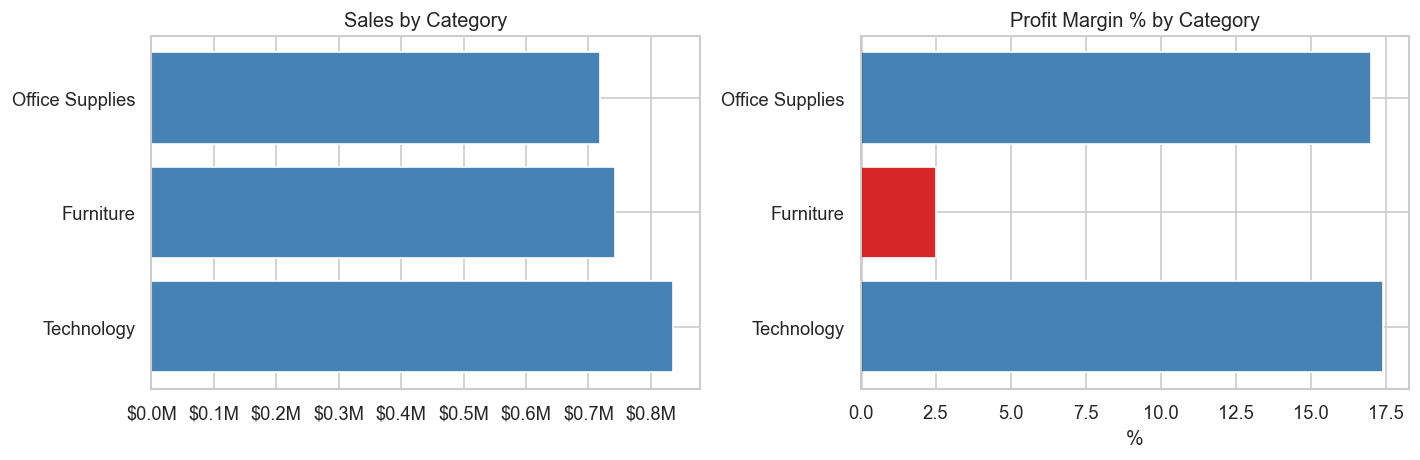

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(cat_df['Category'], cat_df['sales'], color='steelblue')
axes[0].set_title('Sales by Category')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].barh(cat_df['Category'], cat_df['margin_pct'],
             color=['#d62728' if v < 5 else 'steelblue' for v in cat_df['margin_pct']])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit Margin % by Category')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.savefig(VISUALS_PATH / "02a_category_performance.png", bbox_inches="tight")
plt.show()

**Sales, Profit, and Margin by Sub-Category**

=== Sub-Category (sorted by profit) ===


,Sub-Category,Category,sales,items_sold,profit,margin_pct
0,Copiers,Technology,"149,528.0",68,"55,618.0",37.2
1,Phones,Technology,"330,007.0",889,"44,516.0",13.5
2,Accessories,Technology,"167,380.0",775,"41,937.0",25.1
3,Paper,Office Supplies,"78,479.0",1370,"34,054.0",43.4
4,Binders,Office Supplies,"203,413.0",1523,"30,222.0",14.9
5,Chairs,Furniture,"328,168.0",616,"26,602.0",8.1
6,Storage,Office Supplies,"223,844.0",846,"21,279.0",9.5
7,Appliances,Office Supplies,"107,532.0",466,"18,138.0",16.9
8,Furnishings,Furniture,"91,705.0",957,"13,059.0",14.2
9,Envelopes,Office Supplies,"16,476.0",254,"6,964.0",42.3


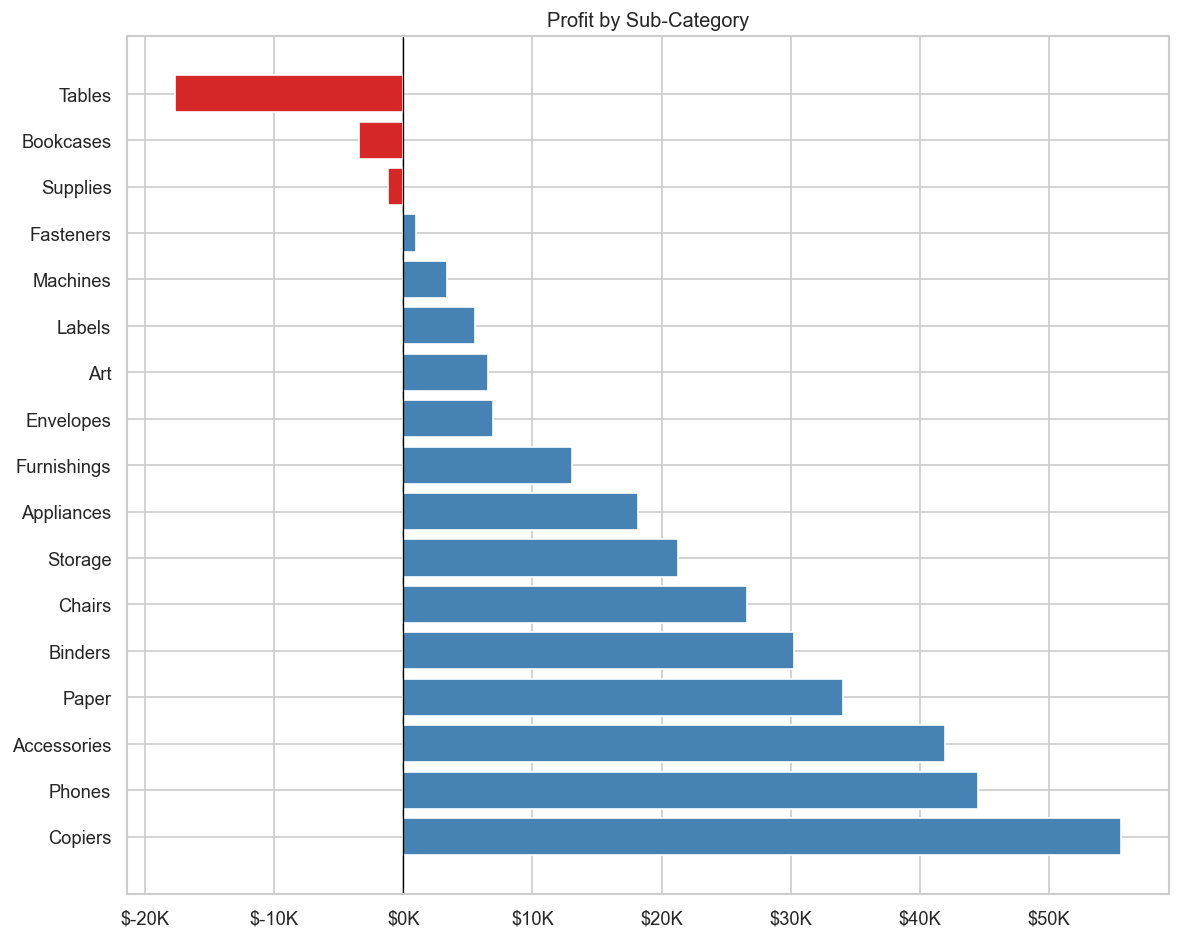

In [6]:
print('=== Sub-Category (sorted by profit) ===')
display(sub_df)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if v < 0 else 'steelblue' for v in sub_df['profit']]
ax.barh(sub_df['Sub-Category'], sub_df['profit'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Profit by Sub-Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(VISUALS_PATH / "02b_subcategory_profit.png", bbox_inches="tight")
plt.show()

**Key Observations:**
- Revenue is balanced across categories (**31–36% each**), but profit quality is highly uneven: **Technology (17.4%)** and **Office Supplies (17%)** generate healthy margins, while **Furniture (2.5%)** strongly underperforms.

- Furniture appears to be the main margin drag at the category level: despite accounting for 32.3% of total sales, it contributes only 6.4% of total profit, indicating that strong revenue generation is not translating into profitability.

- Losses are concentrated in a few sub-categories: **Tables (–$17.7K)** and **Bookcases (–$3.5K)** within Furniture, plus **Supplies (–$1.2K)** in Office Supplies.

At this point, the data suggests that Furniture appears structurally margin-constrained under the observed pricing and discount patterns. It includes two of the three loss-making sub-categories — Tables and Bookcases — which suggests that the profitability issue is structural rather than incidental. From here, the analysis should examine whether discounting is further amplifying this margin leakage.

---
#### 2.2.2 Global Breakeven Discount

,discount_bucket,items,avg_discount_pct,sales,profit,margin_pct
0,0%,4798,0.0,"1,087,908.0","320,988.0",29.5
1,1-10%,94,10.0,"54,369.0","9,029.0",16.6
2,11-20%,3709,19.9,"792,153.0","91,756.0",11.6
3,21-30%,226,30.0,"102,945.0","-10,357.0",-10.1
4,31-50%,310,41.6,"195,315.0","-48,448.0",-24.8
5,>50%,856,71.9,"64,229.0","-76,559.0",-119.2


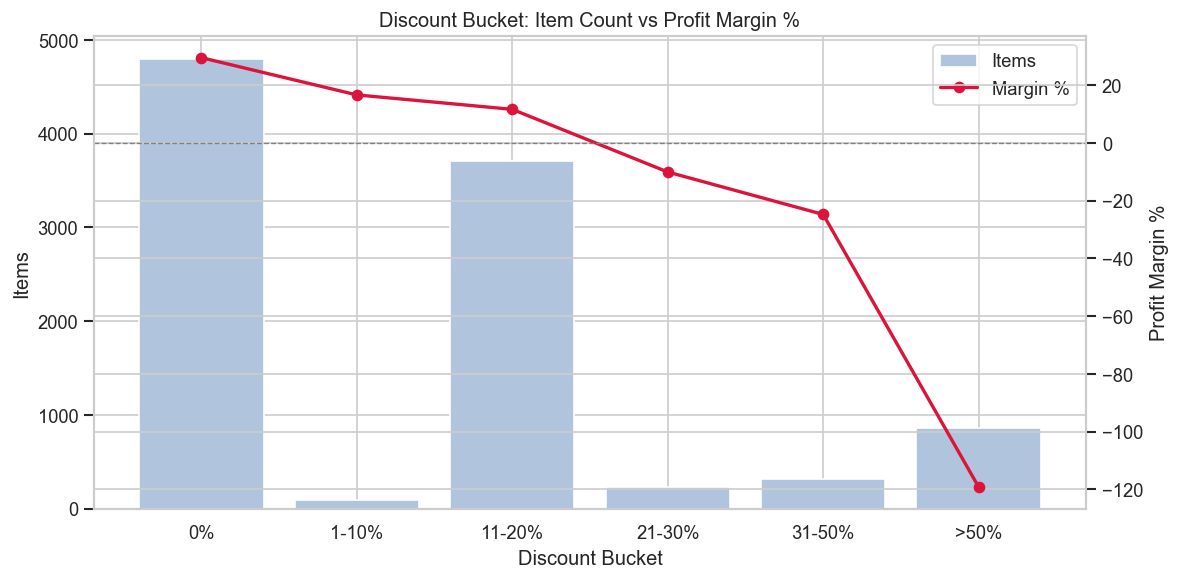

In [7]:
results  = run_sql_file(SQL_PATH / '03_discount_impact.sql')
disc_df  = results[0]
display(disc_df)

fig, ax1 = plt.subplots(figsize=(10, 5))

bar_colors = ['#d62728' if v < 0 else 'steelblue' for v in disc_df['margin_pct']]
bars = ax1.bar(disc_df['discount_bucket'], disc_df['items'], color='lightsteelblue', label='Items')
ax1.set_ylabel('Items')
ax1.set_xlabel('Discount Bucket')

ax2 = ax1.twinx()
ax2.plot(disc_df['discount_bucket'], disc_df['margin_pct'], color='crimson',
         marker='o', linewidth=2, label='Margin %')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Profit Margin %')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Discount Bucket: Item Count vs Profit Margin %')
plt.tight_layout()
plt.savefig(VISUALS_PATH / "03_discount_impact.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- Profitability deteriorates sharply as discounts increase: margin falls from **29.5% at 0% discount** to **11.6% at 11–20%**, then turns negative at **21–30% (-10.1%)**.

- The portfolio-level breakeven point is around the **20% discount threshold**. Above this level, discounted items are loss-making on average, making the 20% mark a useful first warning line for pricing-control analysis.

- Discount exposure is not marginal: the **11–20% bucket contains 3,709 items**, making it the second-largest discount group and highly relevant for day-to-day pricing decisions.

- The most severe losses are concentrated in the **>50% discount bucket**, where **856 items** — approximately **8.6% of all items** — generate an average margin of **-119.2%**. In other words, nearly 1 in 10 line-items is sold in an extreme discount zone where the average loss exceeds the sales value.

---
#### 2.2.3 Discount × Category Drill-down

The global curve identifies where profitability breaks on average, but it does not reveal whether all categories tolerate discounting equally. Therefore, it is important to investigate whether the ~20% breakeven threshold applies consistently across Furniture, Office Supplies, and Technology.

=== Margin % by Category x Discount Bucket ===


discount_bucket,0%,1-10%,11-20%,21-30%,31-50%,>50%
Category,,,,,,
Furniture,22.7,15.2,3.1,-10.8,-39.2,-108.1
Office Supplies,29.5,25.1,16.3,NaN,NaN,-119.3
Technology,34.0,24.4,14.6,8.7,-13.3,-125.5



=== Item count by Category x Discount Bucket ===


discount_bucket,0%,1-10%,11-20%,21-30%,31-50%,>50%
Category,,,,,,
Furniture,836.0,76.0,667.0,221.0,167.0,153.0
Office Supplies,"3,129.0",16.0,"2,201.0",NaN,NaN,680.0
Technology,833.0,2.0,841.0,5.0,143.0,23.0


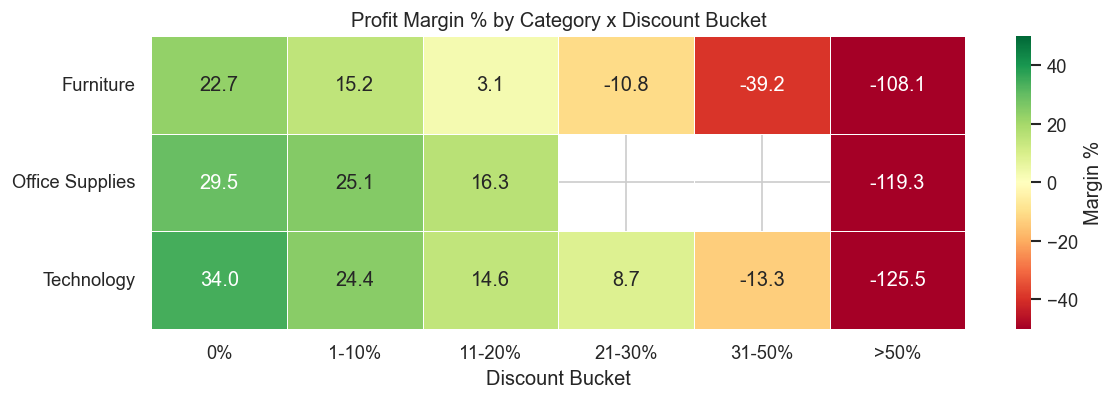

In [8]:
results       = run_sql_file(SQL_PATH / '04_discount_x_category.sql')
disc_cat_df   = results[0]

bucket_order = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%']
disc_cat_df['discount_bucket'] = pd.Categorical(
    disc_cat_df['discount_bucket'], categories=bucket_order, ordered=True)

margin_pivot = disc_cat_df.pivot(
    index='Category', columns='discount_bucket', values='margin_pct'
).reindex(columns=bucket_order)

items_pivot = disc_cat_df.pivot(
    index='Category', columns='discount_bucket', values='items'
).reindex(columns=bucket_order)

print('=== Margin % by Category x Discount Bucket ===')
display(margin_pivot)

print('\n=== Item count by Category x Discount Bucket ===')
display(items_pivot)

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(
    margin_pivot,
    annot=True, fmt='.1f',
    cmap='RdYlGn', center=0, vmin=-50, vmax=50,
    cbar_kws={'label': 'Margin %'},
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_title('Profit Margin % by Category x Discount Bucket')
ax.set_xlabel('Discount Bucket')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(VISUALS_PATH / "09_discount_x_category.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- The global **20% breakeven threshold** hides important category differences. **Furniture** is already fragile before reaching the threshold: its margin falls to only **3.1% at 11–20% discount**, while **Office Supplies (16.3%)** and **Technology (14.6%)** remain comfortably profitable.

- **Furniture appears to be the structurally weakest category under the observed pricing and discount patterns.** Even at **0% discount**, its margin is only **22.7%**, below **Office Supplies (29.5%)** and **Technology (34.0%)**. Once discounts exceed 20%, Furniture becomes loss-making immediately.

- The exposure is also material: **541 Furniture items** are sold above the 20% discount threshold, representing approximately **25.5% of all Furniture line-items**. This suggests that Furniture’s margin problem is not only caused by a few isolated transactions.

- **Office Supplies remains healthy below 20% discount**, but it has a significant extreme-discount problem: **680 Office Supplies items** — approximately **11.3% of all Office Supplies line-items** — fall into the **>50% discount bucket**, where the average margin reaches **-119.3%**.

- Overall, the discount tolerance seems to be category-specific. **Furniture needs earlier intervention**, while **Office Supplies and Technology require controls mainly around extreme discounting**.

---
#### 2.2.4 Customer Segment & Ship Mode Performance

=== Segment ===


,Segment,sales,profit,margin_pct,customers,orders
0,Consumer,"1,161,401.0","134,119.0",11.5,409,2586
1,Corporate,"706,146.0","91,979.0",13.0,236,1514
2,Home Office,"429,372.0","60,311.0",14.0,148,909



=== Ship Mode ===


,Ship Mode,items,sales,profit,margin_pct
0,First Class,1538,"351,428.0","48,970.0",13.9
1,Second Class,1945,"459,194.0","57,447.0",12.5
2,Same Day,543,"128,363.0","15,892.0",12.4
3,Standard Class,5967,"1,357,934.0","164,101.0",12.1


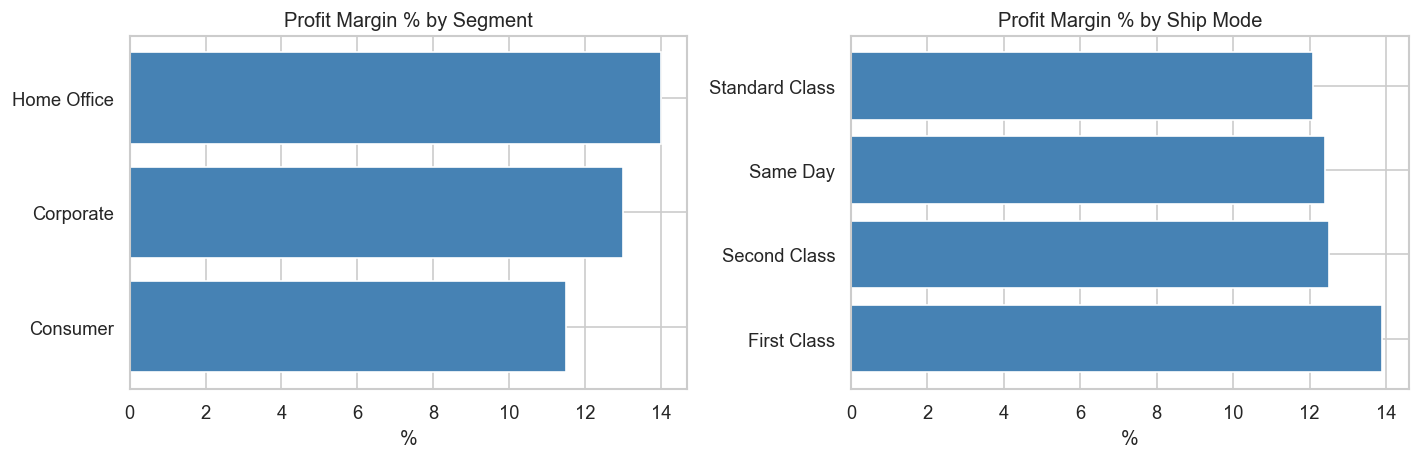

In [9]:
results   = run_sql_file(SQL_PATH / '05_by_segment.sql')
seg_df    = results[0]
ship_df   = results[1]

print('=== Segment ===')
display(seg_df)
print('\n=== Ship Mode ===')
display(ship_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(seg_df['Segment'], seg_df['margin_pct'], color='steelblue')
axes[0].set_title('Profit Margin % by Segment')
axes[0].set_xlabel('%')

axes[1].barh(ship_df['Ship Mode'], ship_df['margin_pct'], color='steelblue')
axes[1].set_title('Profit Margin % by Ship Mode')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.savefig(VISUALS_PATH / "06_segment_shipmode.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- Segment margins are relatively close: **Consumer (11.5%)**, **Corporate (13%)**, and **Home Office (14%)** differ by only **2.5 percentage points**, suggesting that customer segment is not a primary margin driver.

- Ship Mode margins are also narrow (**12.1%–13.9%**). Standard Class carries the largest volume (**$1.36M**) at the lowest margin, while First Class has the highest margin but lower volume.

Overall, Segment and Ship Mode do not show the same sharp margin gaps observed in categories and discount buckets. This makes them less likely to be primary drivers of profit leakage, and suggests that the next level of investigation should stay focused on product economics, discount exposure, and geography.

---
#### 2.2.5 Shipping Time by Ship Mode

=== Shipping Time Summary ===


,Ship Mode,orders,min_days,avg_days,max_days
0,Same Day,543,0.0,0.0,1.0
1,First Class,1538,1.0,2.2,4.0
2,Second Class,1945,1.0,3.2,5.0
3,Standard Class,5967,3.0,5.0,7.0


/var/folders/87/h23m9vdx59ld0nj_g0377vc00000gn/T/ipykernel_3402/2358494374.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=mode_order, patch_artist=True, vert=True)


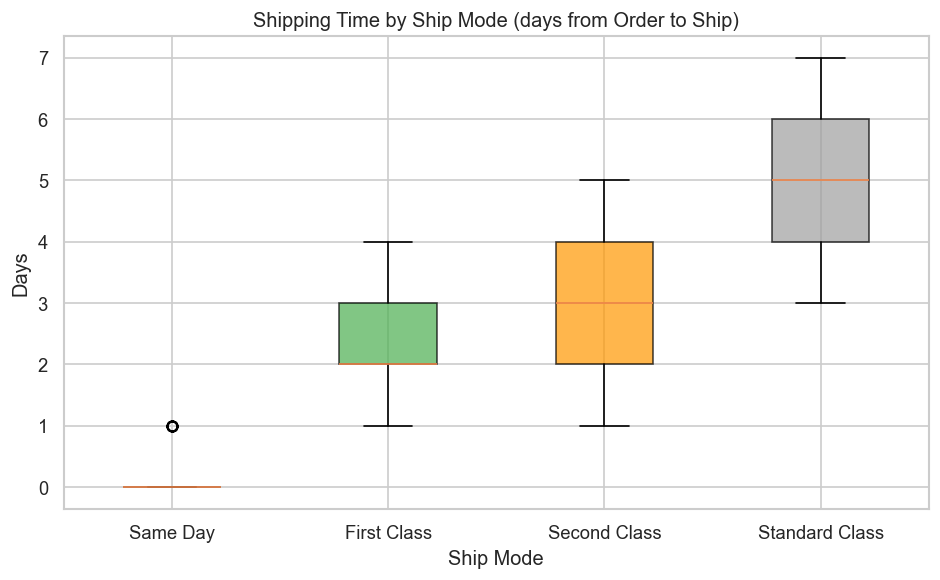

In [10]:
results   = run_sql_file(SQL_PATH / '06_shipping_time.sql')
summary_df = results[0]   # aggregated stats per Ship Mode
raw_df     = results[1]   # per-order ship days for boxplot

print('=== Shipping Time Summary ===')
display(summary_df)

# Order Ship Modes from fastest to slowest for the boxplot
mode_order = summary_df['Ship Mode'].tolist()
raw_df['Ship Mode'] = pd.Categorical(raw_df['Ship Mode'], categories=mode_order, ordered=True)
raw_df = raw_df.sort_values('Ship Mode')

fig, ax = plt.subplots(figsize=(8, 5))

groups = [raw_df.loc[raw_df['Ship Mode'] == m, 'ship_days'].values for m in mode_order]
bp = ax.boxplot(groups, labels=mode_order, patch_artist=True, vert=True)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Shipping Time by Ship Mode (days from Order to Ship)')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('Days')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(VISUALS_PATH / '13_shipping_time.png', dpi=150)
plt.show()

**Key Observation:**

- Shipping tiers are operationally consistent: Same Day, First Class, Second Class, and Standard Class follow the expected speed hierarchy. This suggests that Ship Mode is behaving as expected operationally, but does not appear to explain the major margin gaps identified earlier.


---
### 2.3 Geographic Profitability

The previous section showed that margin leakage is mainly driven by category mix and discount exposure, while Segment and Ship Mode seem not to play a major role. This section tests whether those profitability patterns are geographically concentrated, moving from regional performance to state-level losses and finally to product-region interactions.

---
#### 2.3.1 Regional Overview

=== Region ===


,Region,sales,profit,margin_pct,orders,customers
0,West,"725,458.0","108,418.0",14.9,1611,686
1,East,"678,500.0","91,535.0",13.5,1401,674
2,South,"391,722.0","46,749.0",11.9,822,512
3,Central,"501,240.0","39,706.0",7.9,1175,629


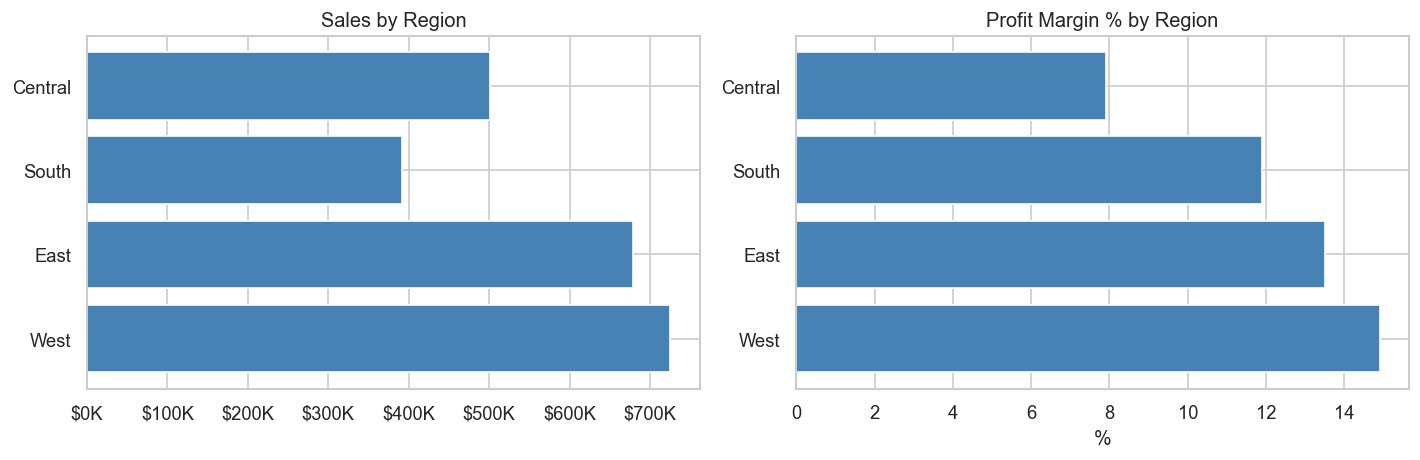

In [11]:
results    = run_sql_file(SQL_PATH / '07_by_region.sql')
region_df  = results[0]
states_df  = results[1]

print('=== Region ===')
display(region_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(region_df['Region'], region_df['sales'], color='steelblue')
axes[0].set_title('Sales by Region')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[1].barh(region_df['Region'], region_df['margin_pct'], color='steelblue')
axes[1].set_title('Profit Margin % by Region')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.savefig(VISUALS_PATH / "04a_region_performance.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- Profitability varies meaningfully by region: **West (14.9%)** and **East (13.5%)** maintain healthy margins, while **Central drops to only 7.9%**, well below the **13.4% average margin of the other three regions**.

- **Central appears to have a structural margin-quality problem**: it is the third-largest region by sales (**$501K**) but produces the weakest margin in the portfolio, suggesting that demand exists but sales are being converted into profit less efficiently.

- This makes Central a priority geography for deeper investigation, especially in connection with the category and discount weaknesses identified earlier.

---
#### 2.3.2 Bottom 10 States by Profit

=== States with Highest Losses ===


,State,Region,sales,profit,margin_pct,loss_abs,cumulative_loss,cumulative_loss_pct_total
0,Texas,Central,"$170,188","$-25,729",-15.1%,"$25,729","$25,729",16.5%
1,Ohio,East,"$77,977","$-16,959",-21.7%,"$16,959","$42,689",27.3%
2,Pennsylvania,East,"$116,512","$-15,560",-13.4%,"$15,560","$58,249",37.3%
3,Illinois,Central,"$80,166","$-12,608",-15.7%,"$12,608","$70,857",45.4%
4,North Carolina,South,"$55,603","$-7,491",-13.5%,"$7,491","$78,347",50.2%
5,Colorado,West,"$32,108","$-6,528",-20.3%,"$6,528","$84,875",54.4%
6,Tennessee,South,"$30,662","$-5,342",-17.4%,"$5,342","$90,217",57.8%
7,Arizona,West,"$35,282","$-3,428",-9.7%,"$3,428","$93,645",60.0%
8,Florida,South,"$89,474","$-3,399",-3.8%,"$3,399","$97,044",62.2%
9,Oregon,West,"$17,431","$-1,190",-6.8%,"$1,190","$98,235",62.9%


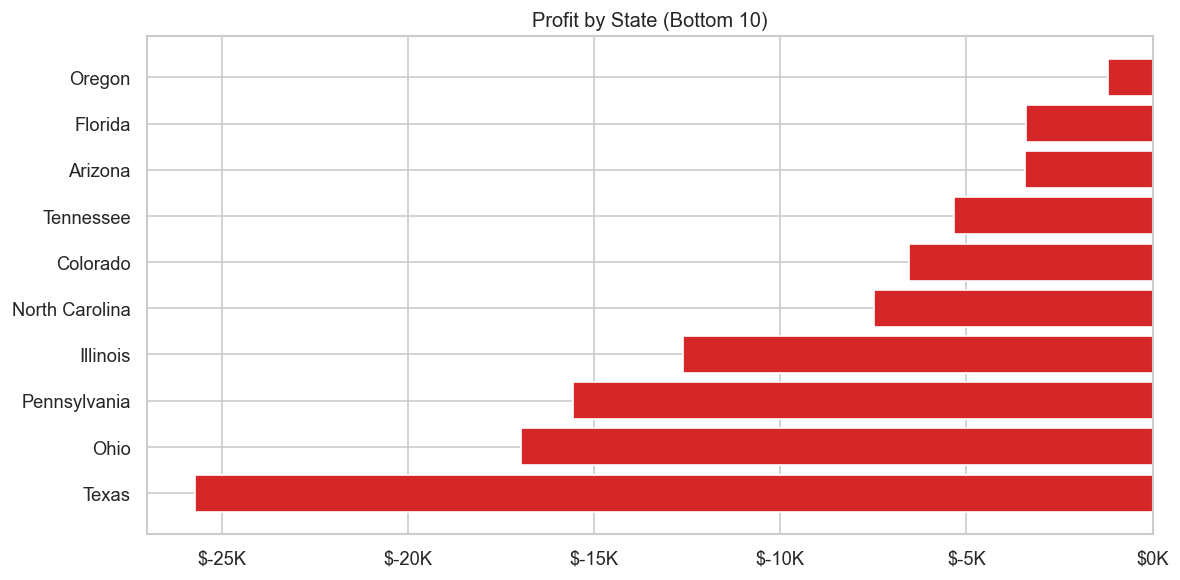

In [12]:
print('=== States with Highest Losses ===')
display(
    states_df.style.format({
        'sales': '${:,.0f}',
        'profit': '${:,.0f}',
        'margin_pct': '{:.1f}%',
        'loss_abs': '${:,.0f}',
        'cumulative_loss': '${:,.0f}',
        'cumulative_loss_pct_total': '{:.1f}%',
    })
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if v < 0 else 'steelblue' for v in states_df['profit']]
ax.barh(states_df['State'], states_df['profit'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Profit by State (Bottom 10)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(VISUALS_PATH / "04b_state_losses.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- State-level losses show a meaningful concentration pattern: the four largest loss states — **Texas (-$25.7K)**, **Ohio (-$17.0K)**, **Pennsylvania (-$15.6K)**, and **Illinois (-$12.6K)** — account for roughly **45% of total losses from loss-making states** over the four-year period. The full Bottom 10 accounts for roughly **63%**, suggesting that losses are concentrated enough to prioritize specific markets, but not limited to only a few states.

- The weakest states are concentrated mainly in **Central and East**. **Texas** and **Illinois** explain much of Central’s weak regional profitability, while **Ohio** and **Pennsylvania** reveal that East’s healthy regional margin masks significant state-level leakage.

- This state-level view narrows the geographic problem from broad regions to a smaller set of high-priority markets, especially **Texas, Ohio, Pennsylvania, and Illinois**.

The state-level view identifies where the largest losses are concentrated, but the business question is whether these losses come from isolated markets or from the same product weaknesses already observed at category and sub-category level.

---
#### 2.3.3 Sub-Category × Region Heatmap

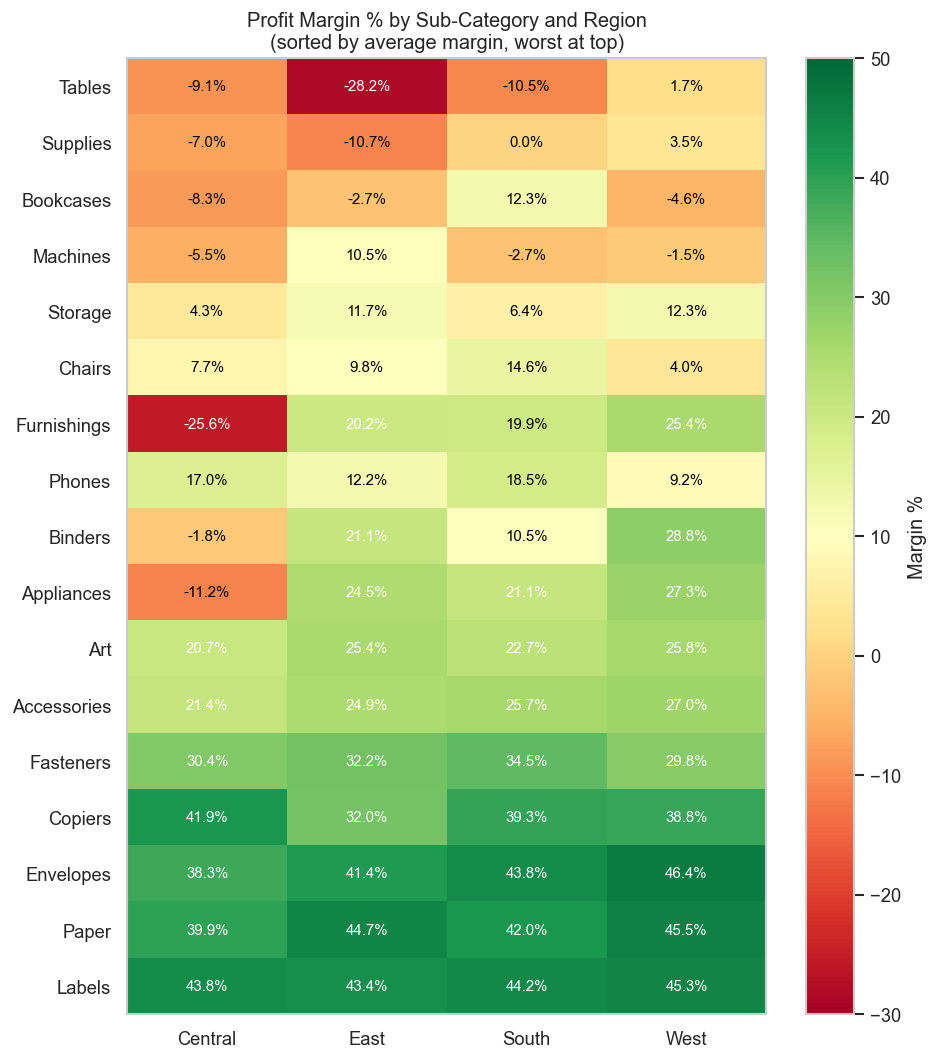

In [13]:
results  = run_sql_file(SQL_PATH / '08_subcategory_region.sql')
cross_df = results[0]

pivot = cross_df.pivot(index='Sub-Category', columns='Region', values='margin_pct')
pivot['_avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('_avg').drop(columns='_avg')

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-30, vmax=50)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.grid(False)

for r in range(len(pivot.index)):
    for c in range(len(pivot.columns)):
        val = pivot.values[r, c]
        color = 'white' if abs(val) > 20 else 'black'
        ax.text(c, r, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color=color)

plt.colorbar(im, ax=ax, label='Margin %')
ax.set_title('Profit Margin % by Sub-Category and Region\n(sorted by average margin, worst at top)')
plt.tight_layout()
plt.savefig(VISUALS_PATH / '15_subcategory_region_heatmap.png', dpi=150)
plt.show()


**Key Observations:**

- The weak sub-categories identified earlier remain problematic across multiple geographies: **Tables**, **Bookcases**, and **Supplies** show negative margins in more than one region, suggesting that these are not purely local issues.

- **Machines deserves attention despite not being one of the main portfolio-level loss-makers**: it is profitable only in **East (10.5%)**, while margins are negative in **Central (-5.5%)**, **South (-2.7%)**, and **West (-1.5%)**.

- **Central shows the broadest regional margin weakness**: nearly half of its sub-categories are loss-making, including several that remain profitable in most other regions, such as **Furnishings (-25.6%)**, **Appliances (-11.2%)**, and **Binders (-1.8%)**.

- The heatmap connects the earlier product-level issue with geography: **Furniture-related weakness is not evenly distributed**, and Central appears to amplify losses beyond the already weak sub-categories.


---
### 2.4 Product & Customer Concentration

The geographic drill-down shows that profit leakage is concentrated in specific state and product-region pockets, rather than being evenly distributed across the business. The next step is to zoom further into the catalog and customer base to determine whether losses and profits are concentrated in a small number of products and accounts.


---
#### 2.4.1 Product Analysis

In [14]:
results      = run_sql_file(SQL_PATH / '09_products.sql')
top_prod_df  = results[0]
loss_prod_df = results[1]
count_loss   = results[2]

top_fmt = {
    'sales': '${:,.0f}',
    'profit': '${:,.0f}',
    'margin_pct': '{:.1f}%',
    'cumulative_profit': '${:,.0f}',
    'cumulative_profit_pct_total': '{:.1f}%',
}
bot_fmt = {
    'sales': '${:,.0f}',
    'profit': '${:,.0f}',
    'margin_pct': '{:.1f}%',
    'loss_abs': '${:,.0f}',
    'cumulative_loss': '${:,.0f}',
    'cumulative_loss_pct_total': '{:.1f}%',
}

print('=== Top 10 Products by Profit ===')
display(top_prod_df.style.format(top_fmt))

print('\n=== Top 10 Products with Highest Losses ===')
display(loss_prod_df.style.format(bot_fmt))

print(f"\nProducts with negative cumulative profit: {count_loss['products_at_loss'].iloc[0]}")

=== Top 10 Products by Profit ===


,Product Name,Category,Sub-Category,sales,profit,margin_pct,times_sold,cumulative_profit,cumulative_profit_pct_total
0,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"$61,600","$25,200",40.9%,5,"$25,200",6.9%
1,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Office Supplies,Binders,"$27,453","$7,753",28.2%,10,"$32,953",9.1%
2,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,"$18,840","$6,984",37.1%,8,"$39,937",11.0%
3,Canon PC1060 Personal Laser Copier,Technology,Copiers,"$11,620","$4,571",39.3%,4,"$44,508",12.2%
4,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",Technology,Machines,"$18,375","$4,095",22.3%,3,"$48,603",13.4%
5,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,"$7,700","$3,773",49.0%,2,"$52,376",14.4%
6,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,"$14,300","$3,718",26.0%,2,"$56,094",15.4%
7,Plantronics Savi W720 Multi-Device Wireless Headset System,Technology,Accessories,"$9,367","$3,696",39.5%,7,"$59,790",16.4%
8,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,"$15,876","$3,345",21.1%,3,"$63,135",17.4%
9,Zebra ZM400 Thermal Label Printer,Technology,Machines,"$6,966","$3,344",48.0%,2,"$66,479",18.3%



=== Top 10 Products with Highest Losses ===


,Product Name,Category,Sub-Category,sales,profit,margin_pct,times_sold,loss_abs,cumulative_loss,cumulative_loss_pct_total
0,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,"$11,100","$-8,880",-80.0%,3,"$8,880","$8,880",11.5%
1,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,"$16,830","$-4,590",-27.3%,4,"$4,590","$13,470",17.5%
2,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,"$8,000","$-3,840",-48.0%,1,"$3,840","$17,310",22.5%
3,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,Furniture,Tables,"$9,918","$-2,876",-29.0%,5,"$2,876","$20,186",26.2%
4,Bush Advantage Collection Racetrack Conference Table,Furniture,Tables,"$9,545","$-1,934",-20.3%,7,"$1,934","$22,120",28.7%
5,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,"$17,965","$-1,878",-10.5%,6,"$1,878","$23,999",31.1%
6,Cisco TelePresence System EX90 Videoconferencing Unit,Technology,Machines,"$22,638","$-1,811",-8.0%,1,"$1,811","$25,810",33.5%
7,Martin Yale Chadless Opener Electric Letter Opener,Office Supplies,Supplies,"$16,656","$-1,299",-7.8%,6,"$1,299","$27,109",35.2%
8,Balt Solid Wood Round Tables,Furniture,Tables,"$6,519","$-1,201",-18.4%,4,"$1,201","$28,310",36.7%
9,BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,Furniture,Tables,"$1,706","$-1,148",-67.3%,3,"$1,148","$29,458",38.2%



Products with negative cumulative profit: 302


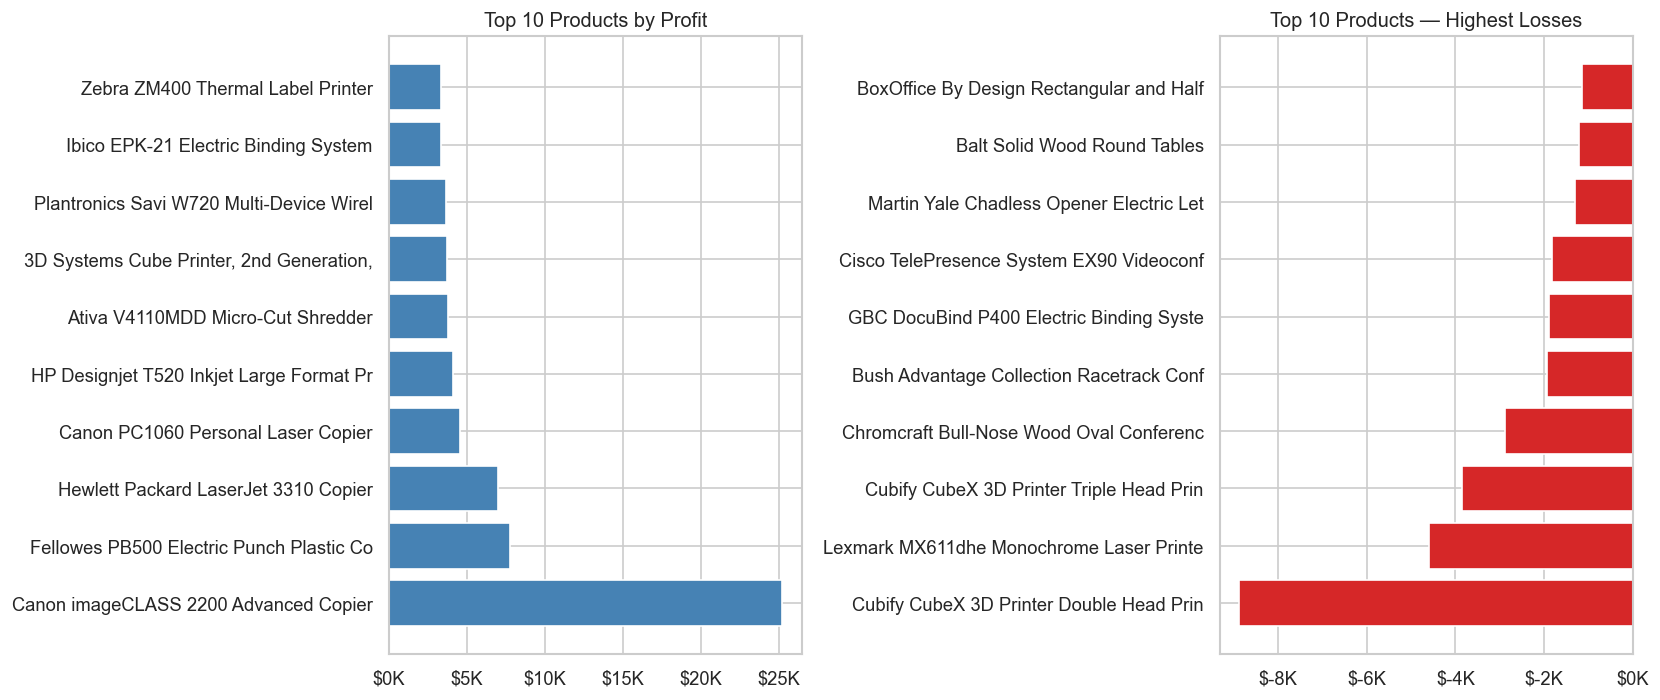

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_prod_df['Product Name'].str[:40], top_prod_df['profit'], color='steelblue')
axes[0].set_title('Top 10 Products by Profit')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[1].barh(loss_prod_df['Product Name'].str[:40], loss_prod_df['profit'], color='#d62728')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 10 Products — Highest Losses')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(VISUALS_PATH / "07_product_analysis.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- Product-level profitability mirrors the earlier sub-category findings: **Copiers** dominate the top-profit ranking, with multiple Canon and HP copier models among the strongest contributors.

- The **Canon imageCLASS 2200 Advanced Copier** is the single largest product-level profit contributor, generating **+$25.2K** with a **40.9% margin** from only **5 sales**. This shows that a small number of high-value SKUs can materially lift overall profitability.

- **Machines behaves as a high-variance sub-category**: several Machine products appear among the top profit contributors, but the largest product-level loss also comes from Machines — **Cubify CubeX 3D Printer Double Head Print (-$8.9K, -80.0% margin)**. This suggests that Machine profitability depends heavily on SKU-level pricing and discount execution.

- Product profit and loss concentration are asymmetric: the top-10 profit products account for **18.3% of total profit from profit-making products**, while the bottom-10 loss products account for **38.2% of total loss from loss-making products**. This suggests that product-level losses are more concentrated than product-level gains, making the worst loss-making SKUs priority candidates for Phase 2 review.

- Furniture-related losses remain visible at product level: several bottom-loss products belong to **Tables**, reinforcing the earlier finding that Furniture’s weakness is not only category-level but also concentrated in specific loss-making SKUs.

- Not all problematic sub-categories behave the same: **Tables** appears consistently loss-prone, **Machines** shows high variance with both major winners and major losers, and **Copiers** concentrates strong profit contribution. The three largest loss-making SKUs are all **Machines** and together account for **22.5% of total product-level losses**, making Machines a priority candidate for SKU-level pricing and discount review in Phase 2.

Overall, this suggests that Phase 2 should distinguish between **structurally weak SKUs**, **high-variance SKUs**, and **strong profit anchors**, rather than applying one generic product strategy across all sub-categories.

---
#### 2.4.2 Top-20 Customers by Sales

In [16]:
results       = run_sql_file(SQL_PATH / '10_customers.sql')
top_by_sales  = results[0]
top_profit    = results[1]
bot_profit    = results[2]
cust_dist     = results[3]
pareto_df     = results[4]

=== Top 20 Customers by Sales ===


,Customer Name,Segment,Region,orders,sales,profit,margin_pct
0,Sean Miller,Home Office,South,2,"23,669.0","-1,787.0",-7.6
1,Tamara Chand,Corporate,Central,2,"18,437.0","8,745.0",47.4
2,Raymond Buch,Consumer,West,2,"14,345.0","6,807.0",47.5
3,Tom Ashbrook,Home Office,East,2,"13,723.0","4,599.0",33.5
4,Adrian Barton,Consumer,Central,5,"12,182.0","5,363.0",44.0
5,Becky Martin,Consumer,Central,1,"10,540.0","-1,879.0",-17.8
6,Hunter Lopez,Consumer,East,2,"10,523.0","5,046.0",48.0
7,Bill Shonely,Corporate,East,2,"10,022.0","2,559.0",25.5
8,Sanjit Chand,Consumer,Central,1,"9,900.0","4,669.0",47.2
9,Greg Tran,Consumer,East,5,"9,383.0","1,749.0",18.6



Avg orders/customer — top-20 by sales: 2.8  (global benchmark: 6.3)


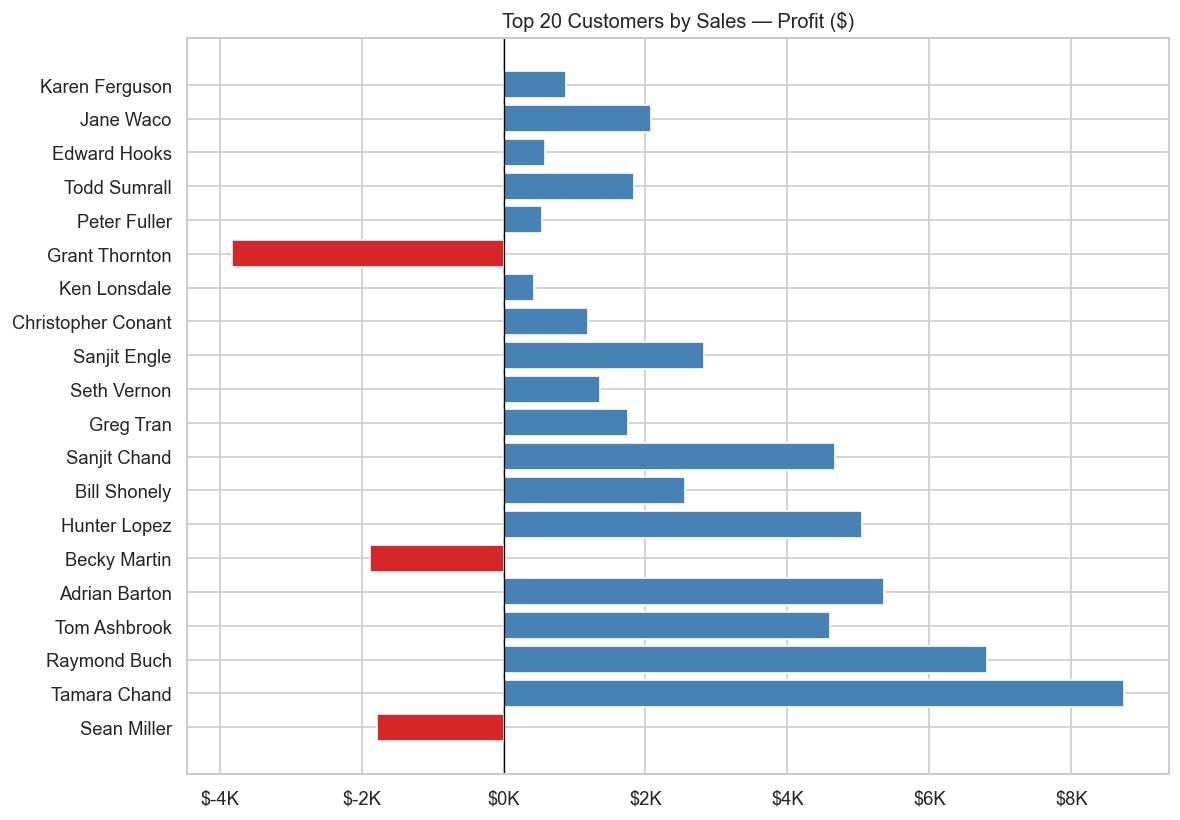

In [17]:
print('=== Top 20 Customers by Sales ===')
display(top_by_sales)

# Recurrence: avg orders per customer in this subset, vs global benchmark
avg_orders_top_sales = top_by_sales['orders'].mean()
global_avg_orders    = kpis.loc['total_orders', 'Value'] / kpis.loc['total_customers', 'Value']
print(f"\nAvg orders/customer — top-20 by sales: {avg_orders_top_sales:.1f}  "
      f"(global benchmark: {global_avg_orders:.1f})")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if v < 0 else 'steelblue' for v in top_by_sales['profit']]
ax.barh(top_by_sales['Customer Name'], top_by_sales['profit'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Customers by Sales — Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(VISUALS_PATH / "08_customer_profit.png", bbox_inches="tight")
plt.show()


**Key Observations:**

- High revenue does not guarantee customer value: **Sean Miller ($23.7K sales)**, **Becky Martin ($10.5K)**, and **Grant Thornton ($8.2K)** rank among the top-20 customers by sales while generating negative cumulative profit.

- The top-sales group appears less recurrent than the average customer: the top-20 customers by sales average only **2.8 orders per customer**, compared with the global benchmark of **6.3**. This suggests that high revenue is often driven by a small number of large orders rather than sustained repeat purchasing.

- This suggests that large customer revenue may be driven by a small number of high-ticket orders rather than recurring profitable behavior, making deal-level pricing and discount review especially important.

- **Grant Thornton** is the clearest red flag in this view: despite ranking among the highest-spending customers, the account generated **-$3.8K profit** with a **-46.8% margin**.


---
#### 2.4.3 Top / Bottom 20 Customers by Profit

=== Top 20 Customers by Profit ===


,Customer Name,Segment,Region,orders,sales,profit,margin_pct,cumulative_profit,cumulative_profit_pct_total
0,Tamara Chand,Corporate,Central,2,"$18,437","$8,745",47.4%,"$8,745",2.2%
1,Raymond Buch,Consumer,West,2,"$14,345","$6,807",47.5%,"$15,552",3.9%
2,Adrian Barton,Consumer,Central,5,"$12,182","$5,363",44.0%,"$20,915",5.2%
3,Hunter Lopez,Consumer,East,2,"$10,523","$5,046",48.0%,"$25,961",6.5%
4,Sanjit Chand,Consumer,Central,1,"$9,900","$4,669",47.2%,"$30,629",7.6%
5,Tom Ashbrook,Home Office,East,2,"$13,723","$4,599",33.5%,"$35,229",8.8%
6,Christopher Martinez,Consumer,South,2,"$6,682","$3,197",47.8%,"$38,426",9.6%
7,Daniel Raglin,Home Office,East,2,"$6,938","$3,050",44.0%,"$41,476",10.3%
8,Sanjit Engle,Consumer,South,1,"$8,805","$2,825",32.1%,"$44,302",11.0%
9,Andy Reiter,Consumer,Central,1,"$5,803","$2,602",44.8%,"$46,904",11.7%



=== Bottom 20 Customers by Profit ===


,Customer Name,Segment,Region,orders,sales,profit,margin_pct,loss_abs,cumulative_loss,cumulative_loss_pct_total
0,Cindy Stewart,Consumer,East,1,"$5,017","$-6,892",-137.4%,"$6,892","$6,892",6.0%
1,Grant Thornton,Corporate,South,1,"$8,167","$-3,825",-46.8%,"$3,825","$10,718",9.3%
2,Luke Foster,Consumer,Central,2,"$2,681","$-3,806",-142.0%,"$3,806","$14,523",12.6%
3,Sharelle Roach,Home Office,West,1,"$2,613","$-3,424",-131.0%,"$3,424","$17,948",15.5%
4,Henry Goldwyn,Corporate,Central,2,"$1,891","$-2,931",-155.0%,"$2,931","$20,879",18.0%
5,Nathan Cano,Consumer,Central,3,"$1,747","$-2,333",-133.5%,"$2,333","$23,211",20.1%
6,Natalie Fritzler,Consumer,East,2,"$4,864","$-2,057",-42.3%,"$2,057","$25,268",21.8%
7,Becky Martin,Consumer,Central,1,"$10,540","$-1,879",-17.8%,"$1,879","$27,147",23.5%
8,Joseph Holt,Consumer,South,1,"$4,298","$-1,862",-43.3%,"$1,862","$29,009",25.1%
9,Sean Miller,Home Office,South,2,"$23,669","$-1,787",-7.6%,"$1,787","$30,797",26.6%



Avg orders/customer — top-20 by profit:    2.4
Avg orders/customer — bottom-20 by profit: 2.1


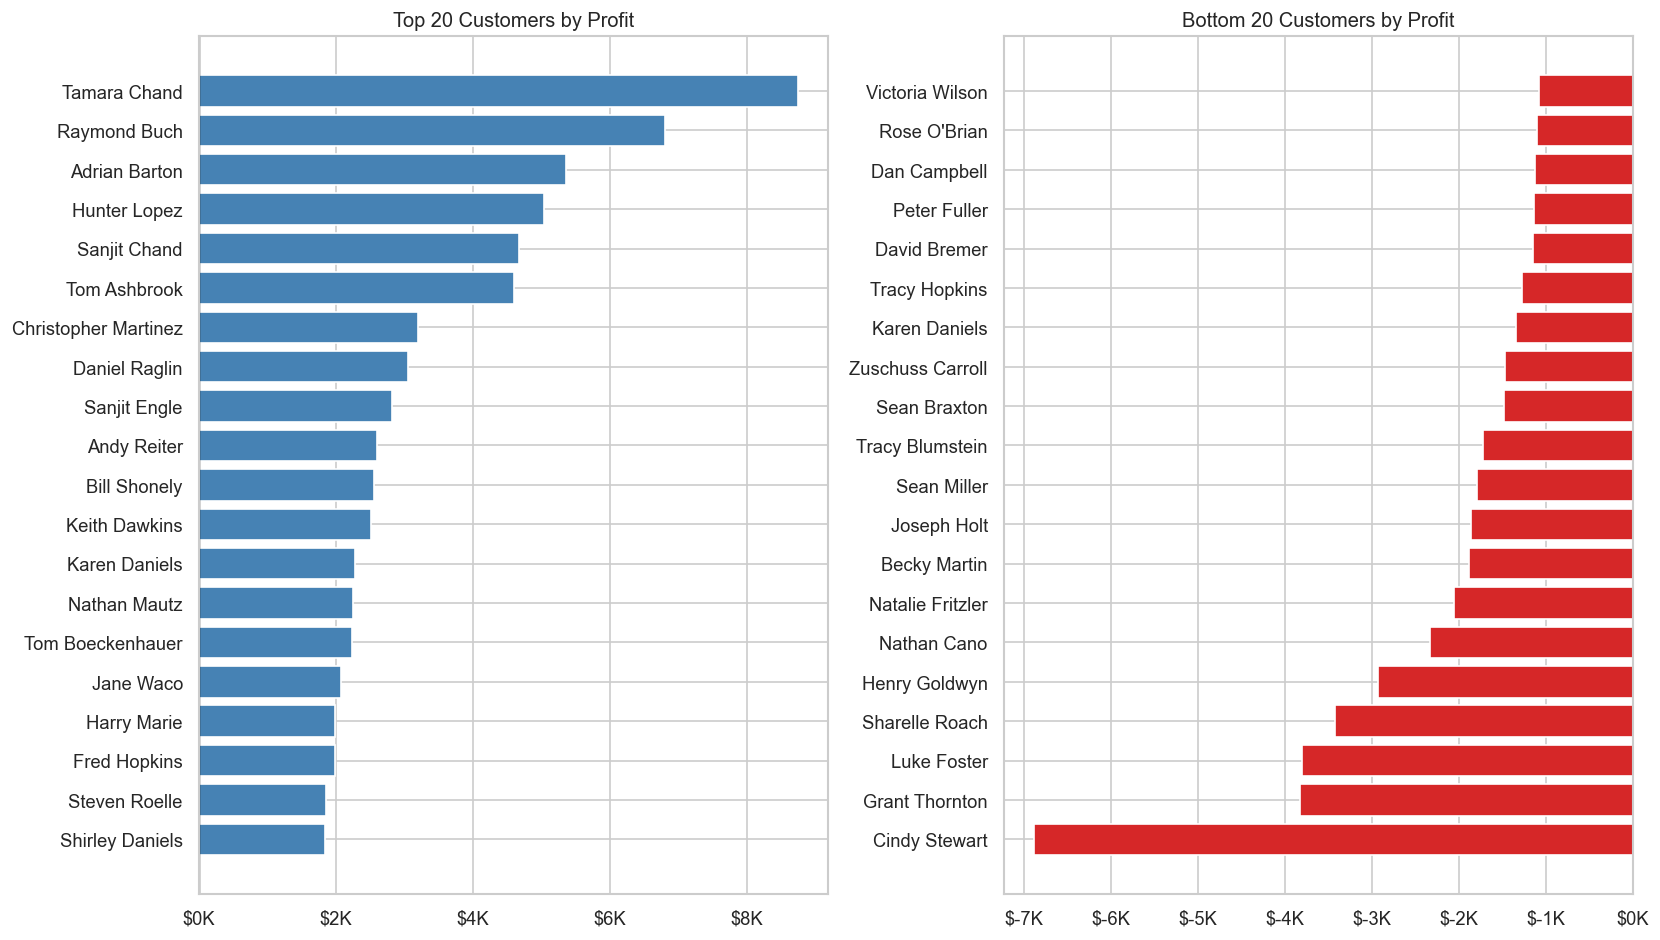

In [18]:
top_fmt = {
    'sales': '${:,.0f}',
    'profit': '${:,.0f}',
    'margin_pct': '{:.1f}%',
    'cumulative_profit': '${:,.0f}',
    'cumulative_profit_pct_total': '{:.1f}%',
}
bot_fmt = {
    'sales': '${:,.0f}',
    'profit': '${:,.0f}',
    'margin_pct': '{:.1f}%',
    'loss_abs': '${:,.0f}',
    'cumulative_loss': '${:,.0f}',
    'cumulative_loss_pct_total': '{:.1f}%',
}

print('=== Top 20 Customers by Profit ===')
display(top_profit.style.format(top_fmt))

print('\n=== Bottom 20 Customers by Profit ===')
display(bot_profit.style.format(bot_fmt))

# Recurrence: avg orders per customer in each subset
avg_orders_top_profit = top_profit['orders'].mean()
avg_orders_bot_profit = bot_profit['orders'].mean()
print(f"\nAvg orders/customer — top-20 by profit:    {avg_orders_top_profit:.1f}")
print(f"Avg orders/customer — bottom-20 by profit: {avg_orders_bot_profit:.1f}")

top_s = top_profit.sort_values('profit', ascending=True)
bot_s = bot_profit.sort_values('profit', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].barh(top_s['Customer Name'], top_s['profit'], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 20 Customers by Profit')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

axes[1].barh(bot_s['Customer Name'], bot_s['profit'], color='#d62728')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Bottom 20 Customers by Profit')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(VISUALS_PATH / "10_customer_top_bottom_profit.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- Extreme customer-level outcomes appear to be driven by a small number of high-impact transactions: both the top-20 profit customers (**2.4 orders/customer**) and bottom-20 profit customers (**2.1 orders/customer**) have far fewer orders than the global customer average (**6.3**).

- Customer profit and loss concentration are asymmetric: the top-20 profit customers account for **17.0% of total profit from profit-making customers**, while the bottom-20 loss customers account for **37.7% of total loss from loss-making customers**. This suggests that customer-level losses are more concentrated than customer-level gains.

- Customer profitability is not primarily explained by order frequency in the extreme tails, but by the economics of specific orders — likely product mix, discounting, or deal-level pricing.

- Several bottom-profit customers show margins below **-100%**, meaning their losses exceeded their sales value. These are not simply low-margin accounts; they represent severe transaction-level profitability failures.

- **Grant Thornton** remains an important account-level red flag because it appears both among the top customers by sales and among the worst customers by profit, making it a clear candidate for Phase 2 account/order decomposition.

- Loss-making customers are concentrated in **Central and East**, reinforcing the regional weakness patterns identified in Section 2.3.

---
#### 2.4.4 Profit Distribution Buckets

=== Customer Profit Distribution ===


,profit_bucket,customers,share_pct
0,Heavy loss (< -1000),19,2.4
1,Loss (-1000 to 0),136,17.2
2,Low profit (0 to 500),417,52.6
3,Mid profit (500 to 2000),196,24.7
4,High profit (> 2000),25,3.2


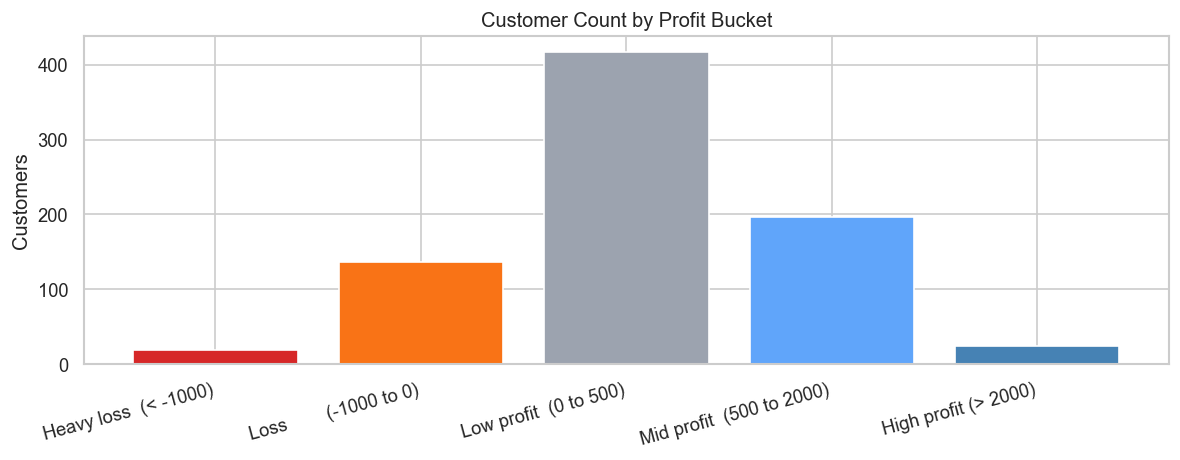

In [19]:
print('=== Customer Profit Distribution ===')
total_customers = cust_dist['customers'].sum()
cust_dist_show = cust_dist.copy()
cust_dist_show['share_pct'] = (cust_dist_show['customers'] / total_customers * 100).round(1)
display(cust_dist_show)

bucket_order = [
    'Heavy loss  (< -1000)',
    'Loss        (-1000 to 0)',
    'Low profit  (0 to 500)',
    'Mid profit  (500 to 2000)',
    'High profit (> 2000)',
]
cust_dist_s = cust_dist.copy()
cust_dist_s['profit_bucket'] = pd.Categorical(
    cust_dist_s['profit_bucket'], categories=bucket_order, ordered=True)
cust_dist_s = cust_dist_s.sort_values('profit_bucket')

dist_colors = ['#d62728', '#F97316', '#9CA3AF', '#60A5FA', 'steelblue']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cust_dist_s['profit_bucket'], cust_dist_s['customers'], color=dist_colors)
ax.set_title('Customer Count by Profit Bucket')
ax.set_ylabel('Customers')
ax.set_xlabel('')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(VISUALS_PATH / "11_customer_distribution.png", bbox_inches="tight")
plt.show()


**Key Observations:**

- Most customers generate only modest cumulative value: **417 customers (52.6%)** fall into the low-profit bucket (**$0–$500**), suggesting that the typical account contributes limited profit over the four-year period.

- Nearly one in five customers is net loss-making: **155 customers (19.6%)** generated negative cumulative profit, including **19 heavy-loss accounts (2.4%)** with losses below **-$1,000**.

- High-profit customers are rare: only **25 customers (3.2%)** generated more than **$2,000** in cumulative profit. This suggests that overall profitability depends heavily on protecting a small set of valuable accounts while reducing leakage from loss-making ones.

- The customer base is therefore polarized: a small group of high-profit accounts supports profitability, a broad base of low-profit customers adds limited value, and a meaningful loss-making segment erodes part of the gains.

---
#### 2.4.5 Customer Profit Concentration / Pareto

Ranking all 793 customers by cumulative profit (highest first) and computing the running share of total profit reveals how concentrated earnings really are.

Top 10% (79 customers) → 57.3% of profit
Top 20% (158 customers) → 81.4% of profit
Cumulative profit peaks at 124.9% at 80.1% of customers (635 customers)
After this point, loss-making customers reduce cumulative profit back to 100%.


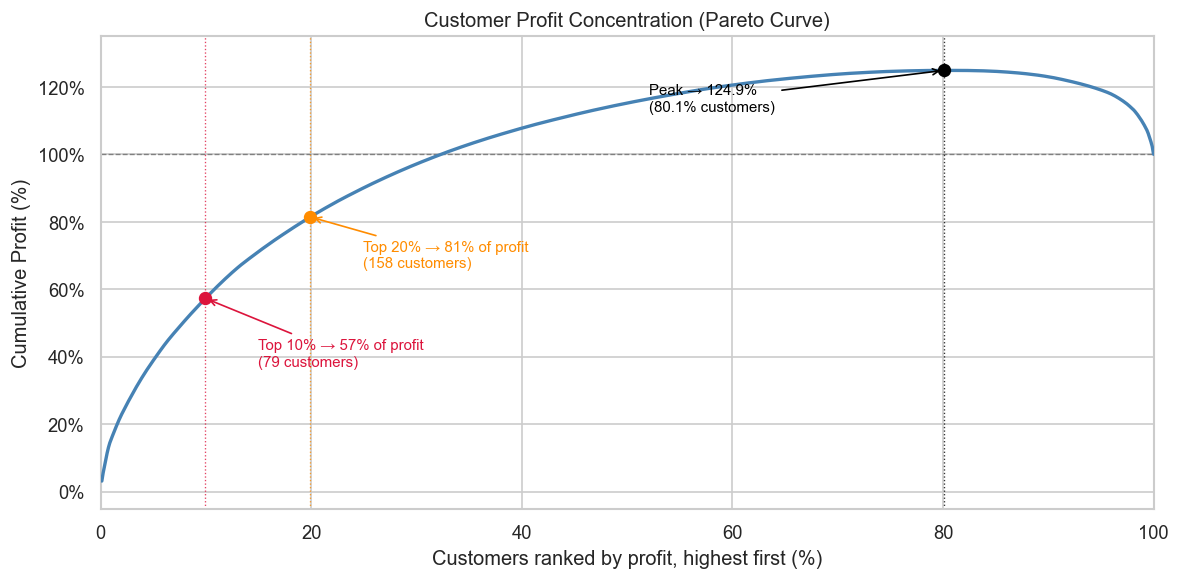

In [20]:
pareto = pareto_df.reset_index(drop=True).copy()
total_p = pareto['profit'].sum()
n_cust = len(pareto)

pareto['cum_profit_pct'] = pareto['profit'].cumsum() / total_p * 100
pareto['customer_pct'] = (pareto.index + 1) / n_cust * 100

top10_n = int(n_cust * 0.10)
top20_n = int(n_cust * 0.20)

pct_at_10 = pareto.loc[top10_n - 1, 'cum_profit_pct']
pct_at_20 = pareto.loc[top20_n - 1, 'cum_profit_pct']

peak_idx = pareto['cum_profit_pct'].idxmax()
peak_pct = pareto.loc[peak_idx, 'cum_profit_pct']
peak_customer_pct = pareto.loc[peak_idx, 'customer_pct']
peak_customer_n = peak_idx + 1

print(f'Top 10% ({top10_n} customers) → {pct_at_10:.1f}% of profit')
print(f'Top 20% ({top20_n} customers) → {pct_at_20:.1f}% of profit')
print(f'Cumulative profit peaks at {peak_pct:.1f}% at {peak_customer_pct:.1f}% of customers ({peak_customer_n} customers)')
print('After this point, loss-making customers reduce cumulative profit back to 100%.')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    pareto['customer_pct'],
    pareto['cum_profit_pct'],
    color='steelblue',
    linewidth=2,
    zorder=3
)

ax.axhline(100, color='gray', linewidth=0.8, linestyle='--')

x10 = pareto.loc[top10_n - 1, 'customer_pct']
x20 = pareto.loc[top20_n - 1, 'customer_pct']

ax.axvline(x10, color='crimson', linewidth=0.8, linestyle=':', alpha=0.8)
ax.axvline(x20, color='darkorange', linewidth=0.8, linestyle=':', alpha=0.8)
ax.axvline(peak_customer_pct, color='black', linewidth=0.8, linestyle=':', alpha=0.8)

ax.plot(x10, pct_at_10, 'o', color='crimson', zorder=5, markersize=7)
ax.plot(x20, pct_at_20, 'o', color='darkorange', zorder=5, markersize=7)
ax.plot(peak_customer_pct, peak_pct, 'o', color='black', zorder=6, markersize=7)

ax.annotate(
    f'Top 10% → {pct_at_10:.0f}% of profit\n({top10_n} customers)',
    xy=(x10, pct_at_10),
    xytext=(x10 + 5, pct_at_10 - 20),
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1),
    fontsize=9,
    color='crimson'
)

ax.annotate(
    f'Top 20% → {pct_at_20:.0f}% of profit\n({top20_n} customers)',
    xy=(x20, pct_at_20),
    xytext=(x20 + 5, pct_at_20 - 15),
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1),
    fontsize=9,
    color='darkorange'
)

ax.annotate(
    f'Peak → {peak_pct:.1f}%\n({peak_customer_pct:.1f}% customers)',
    xy=(peak_customer_pct, peak_pct),
    xytext=(peak_customer_pct - 28, peak_pct - 12),
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
    fontsize=9,
    color='black'
)

ax.set_title('Customer Profit Concentration (Pareto Curve)')
ax.set_xlabel('Customers ranked by profit, highest first (%)')
ax.set_ylabel('Cumulative Profit (%)')
ax.set_xlim(0, 100)
ax.set_ylim(-5, 135)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig(VISUALS_PATH / "12_customer_pareto.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- Customer profit is strongly concentrated: the top **10% of customers** generate **57.3% of realized profit**, while the top **20%** generate **81.4%**. This shows that a relatively small share of accounts drives most of the company’s net profitability.

- The cumulative profit curve peaks at **124.9%** before falling back to **100%**, meaning that profitable customers generate more profit than the business ultimately retains. The gap between the peak and final realized profit represents profit erosion from loss-making customers.

- In monetary terms, the curve implies that profitable customers generate roughly **$357K** in cumulative profit, while loss-making customers offset approximately **$71K**, bringing realized profit back to about **$286K**. This makes loss-making accounts a clear Phase 2 priority, not because they are numerous, but because they materially dilute the gains created by profitable customers.

- The curve also highlights concentration risk: because a small group of customers contributes disproportionately to profit, Phase 2 should examine both sides of the customer base — protecting high-value accounts while diagnosing the pricing, discount, or product-mix patterns behind loss-making accounts.

---
#### 2.4.6 Customer Retention Recurrence (years active)

The metrics in 2.4.2 and 2.4.3 captured *order-frequency* recurrence (avg orders/customer). This sub-section captures the complementary dimension — *years-active* retention: how many distinct calendar years (2014–2017) each customer ordered in, and whether retention scales with profit.

=== Customer Retention Recurrence (cohort by # of active years) ===


,years_active,customers,cust_share_pct,avg_orders_per_customer,avg_profit_per_customer,margin_pct,profit_share_pct
0,1,21,2.6,1.7,115.0,18.6,0.8
1,2,144,18.2,4.1,245.0,12.5,12.3
2,3,322,40.6,5.9,373.0,13.2,42.0
3,4,306,38.6,8.1,420.0,11.8,44.9


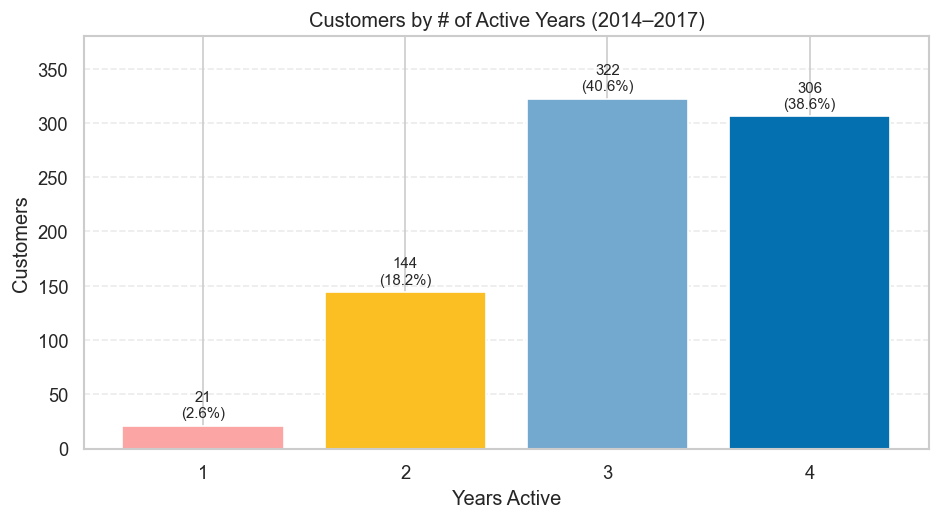

In [21]:
retention_df = run_sql_file(SQL_PATH / '10_customers.sql')[5]

# Add share columns for context
display_df = retention_df.copy()
display_df['cust_share_pct']   = (display_df['customers']    / display_df['customers'].sum()    * 100).round(1)
display_df['profit_share_pct'] = (display_df['total_profit'] / display_df['total_profit'].sum() * 100).round(1)
display_df = display_df[[
    'years_active', 'customers', 'cust_share_pct',
    'avg_orders_per_customer', 'avg_profit_per_customer',
    'margin_pct', 'profit_share_pct',
]]

print('=== Customer Retention Recurrence (cohort by # of active years) ===')
display(display_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
years = retention_df['years_active'].astype(int).astype(str).tolist()
counts = retention_df['customers'].tolist()
bar_colors = ['#FCA5A5', '#FBBF24', '#74A9CF', '#0570B0']  # red → amber → light blue → dark blue
bars = ax.bar(years, counts, color=bar_colors)

for bar, n, share in zip(bars, counts, display_df['cust_share_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{int(n)}\n({share:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_title('Customers by # of Active Years (2014–2017)')
ax.set_xlabel('Years Active')
ax.set_ylabel('Customers')
ax.set_ylim(0, max(counts) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(VISUALS_PATH / '18_customer_retention_recurrence.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Observations:**

- Customer recurrence is relatively healthy at the portfolio level: **79.2% of customers** are active in **3 or 4 different years** (322 + 306 of 793). Only **21 customers (2.6%)** bought in a single year, so Superstore does not appear to have a broad customer-retention problem.

- Profit scales with retention: average profit per customer increases from **$115** for 1-year customers to **$245** for 2-year, **$373** for 3-year, and **$420** for 4-year customers. This increase appears to be driven mainly by higher order frequency (**1.7 → 8.1 orders/customer**) rather than stronger margins.

- The **4-year cohort** is the main profit engine: **38.6% of customers** generate **44.9% of total profit**. Combined with the 3-year cohort, customers active in **3–4 years** account for **86.9% of total profit**.

- The 1-year cohort is small but high-margin (**18.6%**), above the 4-year cohort’s **11.8%**. This suggests that the main retention opportunity may not be first-order profitability, but converting high-quality first-year customers into repeat buyers.

---
### 2.5 Growth & Seasonality

The previous sections identified **where** margin leakage appears: discount-sensitive categories, weak regional pockets, loss-making SKUs, and unprofitable customer accounts. This section asks **when** the leakage appears — whether growth improves margin quality, whether seasonality explains profit pressure, or whether specific periods reveal deeper pricing, mix, or order-level issues.


---
#### 2.5.1 Annual Trend

=== Annual Trend ===


,year,items,orders,sales,profit,margin_pct
0,2014,1992,969,"483,966.0","49,556.0",10.2
1,2015,2102,1038,"470,533.0","61,619.0",13.1
2,2016,2587,1315,"609,206.0","81,795.0",13.4
3,2017,3312,1687,"733,215.0","93,439.0",12.7


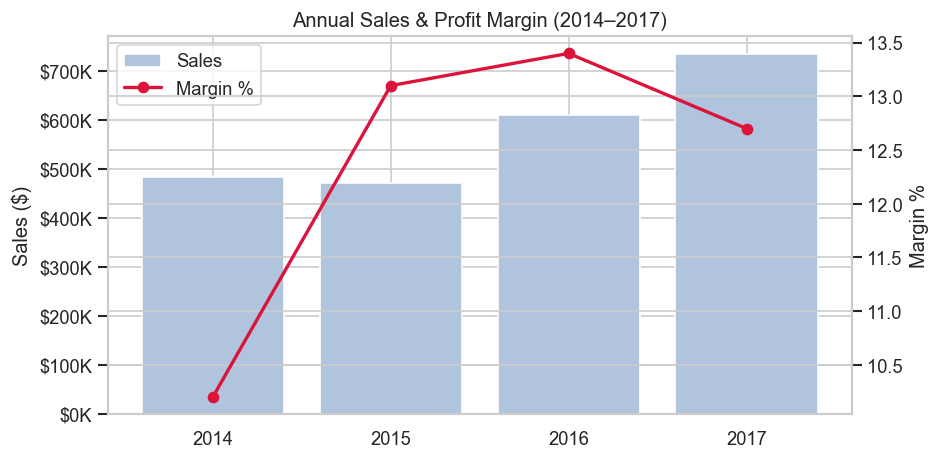

In [22]:
results            = run_sql_file(SQL_PATH / '11_trends.sql')
annual_df          = results[0]
monthly_df         = results[1]
quarterly_year_df  = results[2]
monthly_year_df    = results[3]

print('=== Annual Trend ===')
display(annual_df)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(annual_df['year'], annual_df['sales'], color='lightsteelblue', label='Sales')
ax1.set_ylabel('Sales ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(annual_df['year'], annual_df['margin_pct'], color='crimson',
         marker='o', linewidth=2, label='Margin %')
ax2.set_ylabel('Margin %')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Annual Sales & Profit Margin (2014–2017)')
plt.tight_layout()
plt.savefig(VISUALS_PATH / "05a_annual_trend.png", bbox_inches="tight")
plt.show()


**Key Observations:**

- Revenue grew from **$484K in 2014** to **$733K in 2017**, a **51% increase**, and profit also rose from **$49.6K** to **$93.4K**. The business is growing in absolute terms.

- However, margin quality did not scale with revenue. Margin improved from **10.2% in 2014** to **13.4% in 2016**, but softened to **12.7% in 2017** despite the strongest sales year.

- The 2015 improvement is notable: sales were slightly lower than 2014, yet margin rose from **10.2% to 13.1%**. This suggests that margin quality can improve without revenue growth, likely through better mix, pricing, or discount discipline.

- The 2017 pattern raises the opposite question: sales increased strongly, but margin declined from the 2016 peak. This makes 2017 a priority period for Phase 2 decomposition by discount intensity, product mix, region, and customer/order composition.

---
#### 2.5.2 Quarterly View

=== Quarterly Sales by Year ($K) ===


year,2014,2015,2016,2017
quarter,,,,
Q1,74.4,68.9,93.2,123.1
Q2,86.3,89.1,136.1,133.8
Q3,143.6,130.3,143.8,196.3
Q4,179.6,182.3,236.1,280.1


=== Quarterly Margin by Year (%) ===


year,2014,2015,2016,2017
quarter,,,,
Q1,5.1,13.5,12.3,19.1
Q2,13.0,13.7,12.0,11.6
Q3,8.9,12.9,11.0,13.8
Q4,12.1,12.8,16.2,9.8


=== Avg Margin % by Quarter (weighted, all years) ===


,avg_margin_pct
quarter,
Q1,13.4
Q2,12.4
Q3,11.8
Q4,12.6


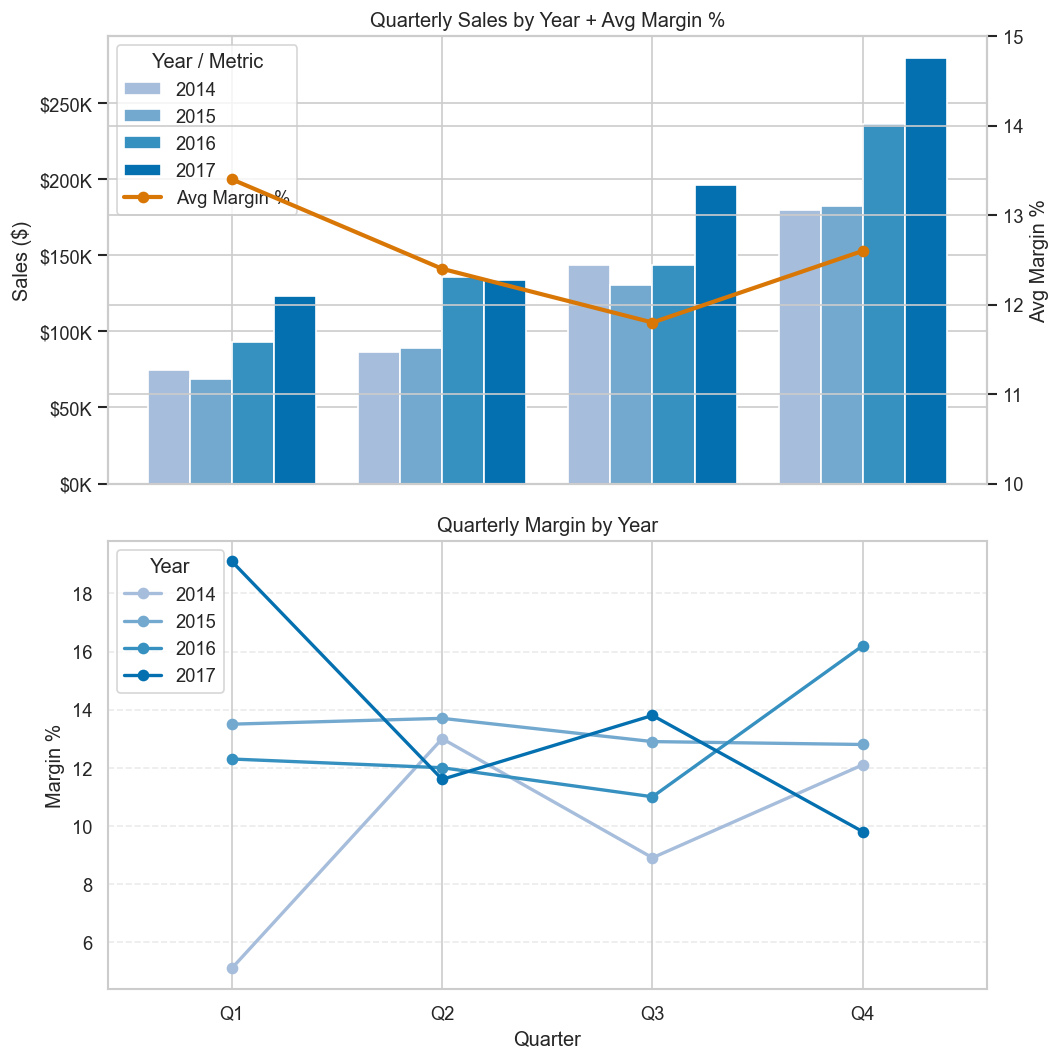

In [23]:
# Quarter-by-year view: one figure, two stacked panels.
#   Top    — grouped sales bars by year + weighted Avg Margin % trendline (secondary axis).
#   Bottom — per-year margin lines (same blue palette as the top bars).
sales_pivot  = quarterly_year_df.pivot(index='quarter', columns='year', values='sales')
margin_pivot = quarterly_year_df.pivot(index='quarter', columns='year', values='margin_pct')

# Weighted average margin per quarter (sum profit / sum sales across 2014–2017),
# consistent with how margin is computed elsewhere in the notebook.
qtr_totals = quarterly_year_df.groupby('quarter').agg(sales=('sales', 'sum'), profit=('profit', 'sum'))
qtr_totals['avg_margin_pct'] = (qtr_totals['profit'] / qtr_totals['sales'] * 100).round(1)
avg_margin = qtr_totals['avg_margin_pct']

print('=== Quarterly Sales by Year ($K) ===')
display((sales_pivot / 1000).round(1))

print('=== Quarterly Margin by Year (%) ===')
display(margin_pivot)

print('=== Avg Margin % by Quarter (weighted, all years) ===')
display(avg_margin.to_frame('avg_margin_pct'))

quarters    = sales_pivot.index.tolist()
years       = sales_pivot.columns.tolist()
x           = list(range(len(quarters)))
bar_w       = 0.2
year_colors = ['#A6BDDB', '#74A9CF', '#3690C0', '#0570B0']  # light → dark blue, oldest → newest

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

# ── Top panel: grouped sales bars + avg margin trendline ─────────────────────
for i, year in enumerate(years):
    offset = (i - (len(years) - 1) / 2) * bar_w
    ax_top.bar([xi + offset for xi in x], sales_pivot[year], width=bar_w,
               label=str(year), color=year_colors[i])
ax_top.set_ylabel('Sales ($)')
ax_top.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e3:.0f}K'))
ax_top.set_title('Quarterly Sales by Year + Avg Margin %')

ax_top_r = ax_top.twinx()
ax_top_r.plot(x, avg_margin.reindex(quarters).values, color='#D97706',
              marker='o', linewidth=2.5, label='Avg Margin %')
ax_top_r.set_ylabel('Avg Margin %')
ax_top_r.set_ylim(10, 15)

lines_l, labels_l = ax_top.get_legend_handles_labels()
lines_r, labels_r = ax_top_r.get_legend_handles_labels()
ax_top.legend(lines_l + lines_r, labels_l + labels_r, loc='upper left', title='Year / Metric')

# ── Bottom panel: per-year margin lines (same blue palette) ──────────────────
for i, year in enumerate(years):
    ax_bot.plot(x, margin_pivot[year].reindex(quarters).values, marker='o', linewidth=2,
                color=year_colors[i], label=str(year))
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(quarters)
ax_bot.set_xlabel('Quarter')
ax_bot.set_ylabel('Margin %')
ax_bot.set_title('Quarterly Margin by Year')
ax_bot.grid(axis='y', linestyle='--', alpha=0.4)
ax_bot.legend(title='Year', loc='upper left')

plt.tight_layout()
plt.savefig(VISUALS_PATH / '14_quarterly_trend.png', dpi=150)
plt.show()

**Key Observations:**

- Revenue seasonality is highly consistent: **Q1 is the weakest quarter** and **Q4 is consistently the strongest**, confirming that the business is structurally back-weighted in sales generation.

- Margin seasonality is much less stable than revenue seasonality. Average quarterly margins range only from **11.8% to 13.4%**, but the year-by-year quarterly margins vary materially within the same quarter.

- This suggests that seasonality alone does not explain margin pressure. If seasonality were the main driver, margins would follow a more stable quarterly pattern across years.

- Q4 2017 is the strongest candidate period for Phase 2 decomposition: it delivered the highest quarterly sales, but margin fell sharply versus Q4 2016. The next question is whether the decline came from deeper discounting, weaker product mix, regional/customer mix, or a few extreme loss orders.

---
#### 2.5.3 Monthly Margins x Year

=== Monthly Margin by Year (%) ===


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
2014,17.2,19.1,0.9,12.5,11.6,14.4,-2.5,19.1,10.2,11.0,11.8,12.9
2015,-18.1,23.5,25.1,12.2,15.5,13.5,11.4,14.5,12.7,9.0,16.4,10.7
2016,15.2,21.8,7.0,7.7,15.2,11.8,11.3,6.6,12.7,27.2,5.1,18.4
2017,16.2,7.9,25.1,2.6,14.3,15.5,15.4,14.3,12.5,11.9,8.2,10.1


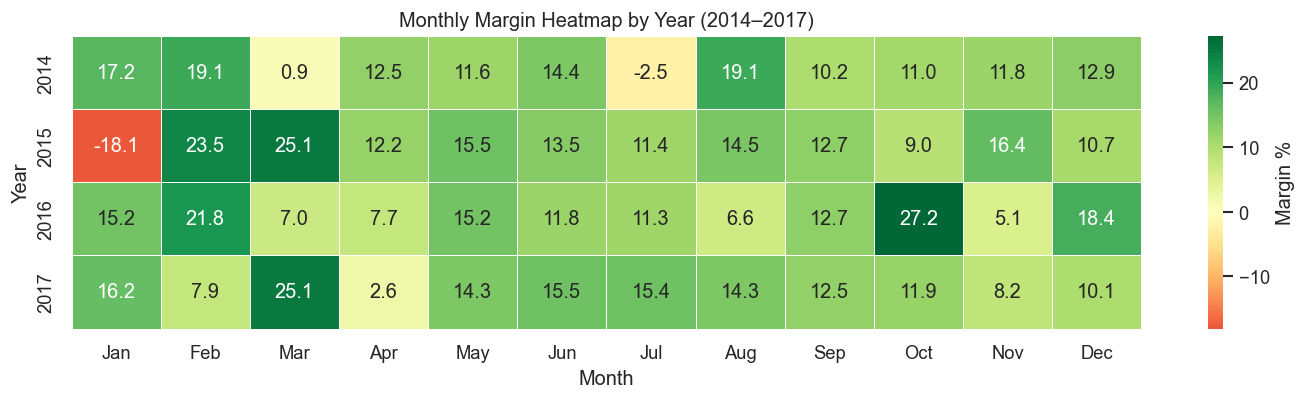

In [24]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

margin_by_year = monthly_year_df.pivot(index='year', columns='month', values='margin_pct')
margin_by_year.columns = [month_labels[m - 1] for m in margin_by_year.columns]

print('=== Monthly Margin by Year (%) ===')
display(margin_by_year)

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(
    margin_by_year,
    cmap='RdYlGn', center=0,
    annot=True, fmt='.1f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Margin %'},
    ax=ax,
)
ax.set_title('Monthly Margin Heatmap by Year (2014–2017)')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(VISUALS_PATH / "17_monthly_margin_heatmap_by_year.png", bbox_inches="tight")
plt.show()

**Key Observations:**

- Monthly margins do not show a stable recurring seasonal pattern. The same month can swing sharply from weak to strong across years, suggesting that month-of-year alone is not a reliable explanation for margin performance.

- The heatmap reveals specific margin events that disappear in aggregate views: **Jan 2015 (-18.1%)** and **Jul 2014 (-2.5%)** are the only negative month-year combinations, but both are hidden when months are averaged across all years.

- Some months show extreme year-to-year variance. **March** ranges from **0.9% in 2014** to **25.1% in 2015 and 2017**, while **October** ranges from **9.0% in 2015** to **27.2% in 2016**. This suggests that monthly profitability is driven more by period-specific mix or transaction composition than by calendar seasonality alone.

- Q4 is not automatically a margin-strength period at the monthly level. Although Q4 is the strongest sales season, monthly margins inside Q4 vary widely, especially in **November** and **December**. This reinforces the need to decompose high-volume periods by discount, category, region, customer, and order mix in Phase 2.


Overall, the time analysis suggests that margin pressure is not explained by seasonality alone. Revenue follows a clear seasonal pattern, but margin does not. This points back to the drivers identified earlier — discount intensity, product/category mix, regional exposure, and customer/order composition — and supports Phase 2 analysis focused on decomposing specific weak periods rather than treating seasonality as the root cause.

---
### 2.6 Distribution & Outliers

Profit ranges from –$6,600 to +$8,400. This section examines how extreme values are distributed and what drives them.

<>:37: SyntaxWarning: invalid escape sequence '\$'
<>:40: SyntaxWarning: invalid escape sequence '\$'
<>:42: SyntaxWarning: invalid escape sequence '\$'
<>:42: SyntaxWarning: invalid escape sequence '\$'
<>:37: SyntaxWarning: invalid escape sequence '\$'
<>:40: SyntaxWarning: invalid escape sequence '\$'
<>:42: SyntaxWarning: invalid escape sequence '\$'
<>:42: SyntaxWarning: invalid escape sequence '\$'
/var/folders/87/h23m9vdx59ld0nj_g0377vc00000gn/T/ipykernel_3402/4075670685.py:37: SyntaxWarning: invalid escape sequence '\$'
  label=f'IQR fence (\${fence_lo:.0f})')
/var/folders/87/h23m9vdx59ld0nj_g0377vc00000gn/T/ipykernel_3402/4075670685.py:40: SyntaxWarning: invalid escape sequence '\$'
  label=f'IQR fence (\${fence_hi:.0f})')
/var/folders/87/h23m9vdx59ld0nj_g0377vc00000gn/T/ipykernel_3402/4075670685.py:42: SyntaxWarning: invalid escape sequence '\$'
  ax2.set_title(f'Profit Distribution — Core Range (P1–P99: \${p1:,.0f} to \${p99:,.0f})')
/var/folders/87/h23m9vdx59ld0nj_g0377vc00

Profit  —  min: $-6,599.98  |  Q1: $1.73  |  median: $8.67  |  Q3: $29.36  |  max: $8,399.98
IQR: $27.63  |  Lower fence: $-39.72  |  Upper fence: $70.81
IQR outliers: 604 below  +  1277 above  =  1881 total (18.8% of rows)
Bottom 1% threshold: $-319.28  |  Top 1% threshold: $580.67


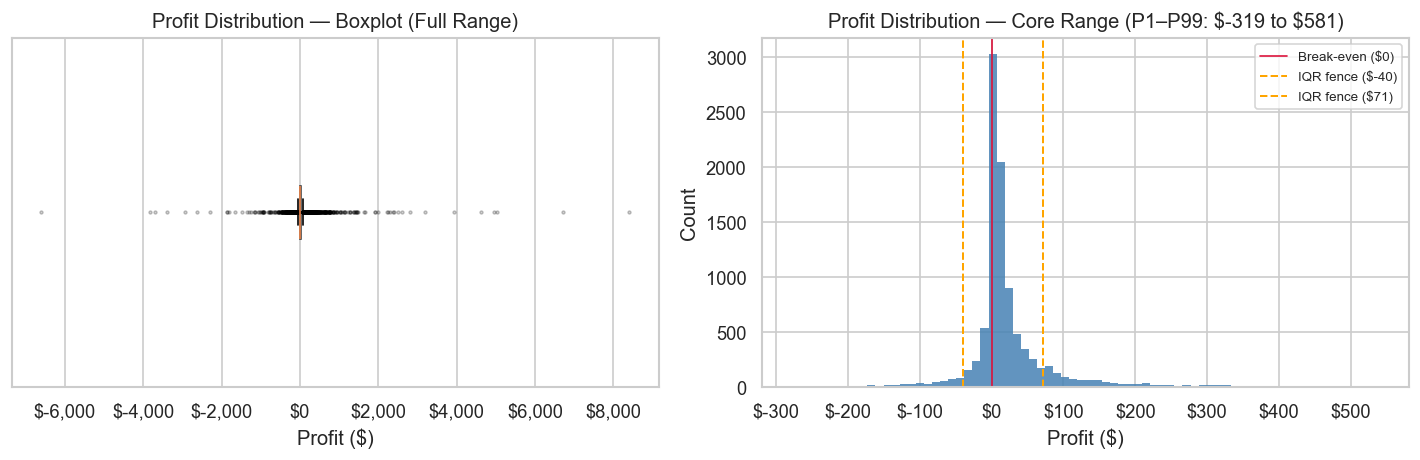

In [25]:
outlier_df = pd.read_sql_query('SELECT Profit, Sales FROM orders', conn)

q1, q3  = outlier_df['Profit'].quantile([0.25, 0.75])
iqr     = q3 - q1
fence_lo = q1 - 1.5 * iqr
fence_hi = q3 + 1.5 * iqr
p1       = outlier_df['Profit'].quantile(0.01)
p99      = outlier_df['Profit'].quantile(0.99)
n_lo     = (outlier_df['Profit'] < fence_lo).sum()
n_hi     = (outlier_df['Profit'] > fence_hi).sum()

print(f'Profit  —  min: ${outlier_df["Profit"].min():,.2f}  |  '
      f'Q1: ${q1:.2f}  |  median: ${outlier_df["Profit"].median():.2f}  |  '
      f'Q3: ${q3:.2f}  |  max: ${outlier_df["Profit"].max():,.2f}')
print(f'IQR: ${iqr:.2f}  |  Lower fence: ${fence_lo:.2f}  |  Upper fence: ${fence_hi:.2f}')
print(f'IQR outliers: {n_lo} below  +  {n_hi} above  =  {n_lo + n_hi} total '
      f'({(n_lo + n_hi) / len(outlier_df) * 100:.1f}% of rows)')
print(f'Bottom 1% threshold: ${p1:.2f}  |  Top 1% threshold: ${p99:.2f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: boxplot — full range, shows the extreme tails / outliers
ax1.boxplot(outlier_df['Profit'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
            flierprops=dict(marker='.', markersize=3, alpha=0.3, color='#d62728'))
ax1.set_title('Profit Distribution — Boxplot (Full Range)')
ax1.set_xlabel('Profit ($)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_yticks([])

# Right: histogram zoomed to the core (P1–P99) so the dense low-profit cluster is readable
core = outlier_df['Profit'][(outlier_df['Profit'] >= p1) & (outlier_df['Profit'] <= p99)]
ax2.hist(core, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax2.axvline(0, color='crimson', linewidth=1, linestyle='-', label='Break-even ($0)')
if p1 <= fence_lo <= p99:
    ax2.axvline(fence_lo, color='orange', linewidth=1.2, linestyle='--',
                label=f'IQR fence (\${fence_lo:.0f})')
if p1 <= fence_hi <= p99:
    ax2.axvline(fence_hi, color='orange', linewidth=1.2, linestyle='--',
                label=f'IQR fence (\${fence_hi:.0f})')
ax2.set_xlim(p1, p99)
ax2.set_title(f'Profit Distribution — Core Range (P1–P99: \${p1:,.0f} to \${p99:,.0f})')
ax2.set_xlabel('Profit ($)')
ax2.set_ylabel('Count')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(VISUALS_PATH / '16_outliers_iqr.png', dpi=150)
plt.show()


**Key Observations:**

- Order-level profit is highly skewed: the median order profit is only **$8.67**, while individual orders range from approximately **-$6.6K** to **+$8.4K**. This shows that a small number of extreme orders can materially influence aggregate profitability.

- The middle 50% of orders is tightly clustered between **$1.73 and $29.36** in profit, but the tails are wide. This confirms that average profit metrics can be misleading without distribution and outlier analysis.

- Outliers are common rather than rare data errors: **1,881 rows (18.8%)** fall outside the IQR thresholds. These reflect real high-value copier sales and deeply discounted loss transactions, not records to automatically remove.

- The 1% tails reinforce the drivers already identified: the bottom tail is linked to severe loss transactions, while the top tail includes high-value winners such as copier-related orders. This supports Phase 2 order-level decomposition of extreme transactions.


---
## 3. Key Findings & Phase 2 Direction

This section converts the EDA observations into diagnostic insights. Phase 1 identifies where profit leakage appears; Phase 2 should explain why it happens and estimate which interventions would create the largest profit lift.


### 3.1 Profitable on the surface, but two early warning signs

Superstore is profitable overall, with **$2.3M in sales**, **$286K in profit**, and a **12.5% margin**. However, **18.7% of line-items are unprofitable** and **52% carry discounts**, showing that the aggregate margin hides widespread transaction-level leakage.

- *Section: 2.1*

**Phase 2 direction:** quantify which combinations of category, discount bucket, region, and customer account explain the highest share of loss-making line-items.

### 3.2 Discount policy should not be one-size-fits-all

The global discount break-even point appears around **20%**, but category-level tolerance varies materially. Furniture is already fragile at **11–20% discount** with only **3.1% margin**, while Technology remains profitable up to the **21–30% bucket**.

- *Section: 2.2.2 · 2.2.3*

**Phase 2 direction:** model discount caps by category/sub-category rather than applying one global rule. Estimate profit lift and revenue risk under alternative discount policies.

### 3.3 Furniture is the main category-level margin drag, but not all Furniture issues are identical

Furniture generates **32% of sales** but only **6.4% of profit**, with a margin of just **2.5%**. Tables and Bookcases are the clearest loss-making sub-categories, but the heatmap shows that some Furniture-related losses are broad while others are region-specific.

- *Sections: 2.2.1 · 2.3.3 · 2.4.1*

**Phase 2 direction:** separate Furniture into three cases: structurally weak sub-categories, region-amplified losses, and SKU-specific failures.

### 3.4 Geography amplifies product-level weaknesses

Central is the weakest region at **7.9% margin**, well below the **13.4% average margin of the other regions**. State-level losses are meaningfully concentrated: Texas, Ohio, Pennsylvania, and Illinois account for roughly **45% of total losses from loss-making states**, while the Bottom 10 accounts for roughly **63%**.

- *Sections: 2.3.1 · 2.3.2 · 2.3.3*

**Phase 2 direction:** decompose Texas, Illinois, Ohio, and Pennsylvania by category, sub-category, discount bucket, customer, and order-level outliers to determine whether each state shares the same loss mechanism.


### 3.5 Product-level losses are more concentrated than product-level gains

The top-10 profit products account for **18.3% of total profit from profit-making products**, while the bottom-10 loss products account for **38.2% of total loss from loss-making products**. This indicates that product-level leakage is more concentrated on the downside.

- *Section: 2.4.1*

**Phase 2 direction:** prioritize the worst loss-making SKUs first. Classify each as a repricing, discount-control, discontinuation, or supplier/cost-review candidate.

### 3.6 Problematic sub-categories require different strategies

Not all problematic sub-categories behave the same. **Tables** appears consistently loss-prone, **Machines** shows high variance with both major winners and major losers, and **Copiers** acts as a strong profit anchor. The three largest loss-making SKUs are all Machines and together account for **22.5% of total product-level losses**.

- *Sections: 2.2.1 · 2.3.3 · 2.4.1*

**Phase 2 direction:** avoid one generic product strategy. Build separate playbooks for structurally weak SKUs, high-variance SKUs, and profit-anchor SKUs.

### 3.7 Customer-level leakage is concentrated on the downside

Customer profit concentration is asymmetric. The top-20 profit customers account for **17.0% of total profit from profit-making customers**, while the bottom-20 loss customers account for **37.7% of total loss from loss-making customers**. Loss-making customers are therefore a more concentrated intervention target than top-customer expansion alone.

- *Sections: 2.4.3 · 2.4.4 · 2.4.5*

**Phase 2 direction:** review the bottom-loss accounts by order, discount, product mix, and region. The goal is not automatically to remove these customers, but to determine which are fixable through pricing controls and which are structurally unprofitable.

### 3.8 Customer profitability extremes appear transaction-driven

The top-sales, top-profit, and bottom-profit customer groups all have far fewer orders than the global average: **2.8**, **2.4**, and **2.1** orders/customer versus **6.3** overall. This suggests that the most extreme customer outcomes are shaped more by the economics of a few high-impact orders than by purchase frequency alone.

- *Sections: 2.4.2 · 2.4.3*

**Phase 2 direction:** perform order-level decomposition for the highest-profit and highest-loss accounts, especially customers that appear in both high-sales and loss-making views, such as Grant Thornton.

### 3.9 Growth increased profit dollars, but 2017 exposed margin-quality risk

Revenue grew **51%** from 2014 to 2017 and profit also increased, so growth is not the problem. The issue is margin quality: margin peaked at **13.4% in 2016** and softened to **12.7% in 2017** despite the strongest sales year.

- *Sections: 2.5.1 · 2.5.2*

**Phase 2 direction:** decompose 2017, especially Q4 2017, by discount intensity, category/sub-category mix, regional mix, customer mix, and extreme orders.

### 3.10 Seasonality is not enough to explain margin pressure

Revenue seasonality is stable: Q1 is weakest and Q4 strongest. Margin seasonality is not stable: quarterly and monthly margins vary materially by year, and specific month-year events such as **Jan 2015 (-18.1%)** and **Jul 2014 (-2.5%)** disappear in aggregate views.

- *Sections: 2.5.2 · 2.5.3*

**Phase 2 direction:** treat weak periods as composition problems rather than pure calendar effects. Analyze specific low-margin periods by product, discount, region, customer, and order mix.

### 3.11 Averages are misleading because order-level profit has fat tails

The median order profit is only **$8.67**, while order-level profit ranges from approximately **-$6.6K to +$8.4K**. The middle 50% of orders is tightly clustered, but the tails are wide and real, not data errors.

- *Section: 2.6*

**Phase 2 direction:** use median, percentiles, and tail decomposition in addition to averages. The most important profit/loss drivers live in the distribution tails.

### EDA Findings Summary

| Priority | Workstream | Key EDA evidence | Source sections | Phase 2 diagnostic question |
|---:|---|---|---|---|
| 1 | Discount policy by category/sub-category | Global break-even appears around **20%**, but tolerance varies by category: **Furniture falls to 3.1% margin at 11–20%**, while **Technology remains profitable up to 21–30%**. | 2.2.2 · 2.2.3 | What discount caps maximize profit by category/sub-category while minimizing revenue risk? |
| 2 | Furniture / Tables / Bookcases diagnosis | **Furniture generates 32% of sales but only 6.4% of profit**, with only **2.5% margin**. Tables and Bookcases are the clearest loss-making Furniture sub-categories, but some losses are regional or SKU-specific. | 2.2.1 · 2.3.3 · 2.4.1 | Are Furniture losses driven by base pricing, discounting, regional mix, SKU-level failures, or supplier/cost structure? |
| 3 | Geographic loss decomposition | **Central has the weakest margin at 7.9%**, versus **13.4% average margin for the other regions**. Texas, Ohio, Pennsylvania, and Illinois account for roughly **45% of total losses from loss-making states**. | 2.3.1 · 2.3.2 · 2.3.3 | Do the main loss states share the same loss mechanism, or does each require a different local explanation? |
| 4 | Loss-making SKU review | Product-level losses are more concentrated than gains: the **bottom-10 loss products account for 38.2% of product-level losses**, while the top-10 profit products account for **18.3% of product-level gains**. | 2.4.1 | Which loss-making SKUs are fixable through repricing or discount controls, and which require discontinuation or cost review? |
| 5 | Product strategy segmentation | **Tables** appears consistently loss-prone, **Machines** shows high variance with both major winners and major losers, and **Copiers** acts as a strong profit anchor. The top 3 loss-making SKUs are all Machines and account for **22.5% of product-level losses**. | 2.2.1 · 2.3.3 · 2.4.1 | How should Phase 2 separate structurally weak SKUs, high-variance SKUs, and profit-anchor SKUs into different action playbooks? |
| 6 | Loss-making customer/account review | Customer leakage is more concentrated on the downside: the **bottom-20 loss customers account for 37.7% of customer-level losses**, while the top-20 profit customers account for **17.0% of customer-level gains**. | 2.4.3 · 2.4.4 · 2.4.5 | Which loss-making accounts are fixable through pricing, discount, product-mix, or order-level controls, and which appear structurally unprofitable? |
| 7 | Order-level customer decomposition | Top-sales, top-profit, and bottom-profit customer groups all have fewer orders than the global average: **2.8**, **2.4**, and **2.1** orders/customer versus **6.3** overall. | 2.4.2 · 2.4.3 | Are extreme customer outcomes driven by a few high-impact orders, and which customers require order-level review first? |
| 8 | 2017 / Q4 margin-quality analysis | Revenue grew **51%** from 2014 to 2017 and profit also increased, but margin peaked at **13.4% in 2016** and softened to **12.7% in 2017** despite the strongest sales year. | 2.5.1 · 2.5.2 | Did 2017 growth, especially Q4 2017, come with deeper discounts, weaker mix, regional concentration, or extreme loss orders? |
| 9 | Low-margin period decomposition | Revenue seasonality is stable, but margin seasonality is not. Month-year events such as **Jan 2015 (-18.1%)** and **Jul 2014 (-2.5%)** disappear in aggregate views. | 2.5.2 · 2.5.3 | Which weak periods are explained by product mix, discount intensity, regional exposure, customer mix, or isolated transactions? |
| 10 | Outlier and tail decomposition | Median order profit is only **$8.67**, while order-level profit ranges from approximately **-$6.6K to +$8.4K**. The middle 50% is tight, but the tails are wide and real. | 2.6 | Which order-level tails explain the largest gains/losses, and how do they map back to known categories, customers, regions, and discounts? |

In [26]:
conn.close()
print('Done. Visuals saved to ../visuals/')

Done. Visuals saved to ../visuals/
